In [115]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import html
from pathlib import Path

from collections import Counter

import nltk
import pandas as pd
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

In [116]:
def _ensure_nltk(pkg: str) -> None:
    try:
        if pkg == "stopwords":
            nltk.data.find("corpora/stopwords")
        elif pkg == "wordnet":
            nltk.data.find("corpora/wordnet")
        elif pkg in ("punkt", "punkt_tab"):
            nltk.data.find(f"tokenizers/{pkg}")
        else:
            nltk.data.find(f"taggers/{pkg}")
    except LookupError:
        nltk.download(pkg)


for _p in ("punkt_tab", "punkt", "stopwords", "wordnet", "averaged_perceptron_tagger_eng", "averaged_perceptron_tagger"):
    _ensure_nltk(_p)

try:
    word_tokenize("ping")
except LookupError:
    nltk.download("punkt")
    nltk.download("punkt_tab")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lucian\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Phần 0: Đọc data - kiểm tra cơ bản

In [117]:
DATA_PATH = "data/Tweets.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


### 1. Thông tin cơ bản về Dataset

In [118]:
# Kiểm tra thông tin DataFrame
print("=" * 60)
print("THÔNG TIN DATASET")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("MÔ TẢ THỐNG KÊ")
print("=" * 60)
display(df.describe())

THÔNG TIN DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-nu

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


### 2. Kiểm tra Missing Values

In [119]:
# Kiểm tra missing values
missing_df = pd.DataFrame({
    'Cột': df.columns,
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})

print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

print(f"\n✓ Tổng số dòng có ít nhất 1 giá trị missing: {df.isnull().any(axis=1).sum():,}")
print(f"✓ Tỷ lệ: {(df.isnull().any(axis=1).sum() / len(df) * 100):.2f}%")

MISSING VALUES ANALYSIS


,Cột,Missing Count,Missing %
negativereason_gold,negativereason_gold,14608,99.78
airline_sentiment_gold,airline_sentiment_gold,14600,99.73
tweet_coord,tweet_coord,13621,93.04
negativereason,negativereason,5462,37.31
user_timezone,user_timezone,4820,32.92
tweet_location,tweet_location,4733,32.33
negativereason_confidence,negativereason_confidence,4118,28.13



✓ Tổng số dòng có ít nhất 1 giá trị missing: 14,638
✓ Tỷ lệ: 99.99%


### 3. Kiểm tra Duplicates

In [120]:
# Kiểm tra duplicates
print("=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)
print(f"✓ Tổng số dòng: {len(df):,}")
print(f"✓ Số dòng duplicate (toàn bộ): {df.duplicated().sum():,}")
print(f"✓ Số dòng duplicate (chỉ text): {df.duplicated(subset=['text']).sum():,}")
print(f"✓ Số dòng unique (text): {df['text'].nunique():,}")

if df.duplicated(subset=['text']).sum() > 0:
    print(f"\n⚠️ Có {df.duplicated(subset=['text']).sum():,} tweets trùng lặp nội dung")
    print("   → Có thể do retweets hoặc copy-paste. Xem xét xử lý nếu cần.")
else:
    print("\n✓ Không có tweets trùng lặp!")

DUPLICATE ANALYSIS
✓ Tổng số dòng: 14,640
✓ Số dòng duplicate (toàn bộ): 36
✓ Số dòng duplicate (chỉ text): 213
✓ Số dòng unique (text): 14,427

⚠️ Có 213 tweets trùng lặp nội dung
   → Có thể do retweets hoặc copy-paste. Xem xét xử lý nếu cần.


# Phần 1. Tiền xử lý NLP cho Tweet (Airline Sentiment)

Dataset: [twitter-airline-sentiment](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment) - phân tích cảm xúc tweet về các hãng hàng không Mỹ (2015).

**Mục tiêu:** Làm sạch và chuẩn hóa text để tạo features tốt cho machine learning models.

**Các bước chính:**
- **Phần 1.1:** Feature Engineering - Kết hợp text sources
- **Phần 1.2:** Text Cleaning - Loại bỏ noise (mentions, hashtags, URLs, emojis)
- **Phần 1.3:** Text Normalization - Chuẩn hóa văn bản
- **Phần 1.4:** Linguistic Processing - Stop words removal & Lemmatization

**Pipeline:** Raw Text → Clean Noise → Normalize → Linguistic Process → Final Text

**12 bước xử lý:**

| Bước | Function | Mô tả | Ví dụ |
|------|----------|-------|-------|
| 1 | Feature Engineering | Kết hợp negativereason + text | |
| 2 | `remove_username()` | Loại @mentions | "@United help" → "help" |
| 3 | `remove_hashtag()` | Loại #hashtags | "#fail service" → "service" |
| 4 | `remove_url()` | Loại URLs | "Check http://..." → "Check" |
| 5 | `remove_emoji()` | Loại emojis | "😡 angry" → "angry" |
| 6 | `decontraction()` | Mở rộng contractions | "can't" → "can not" |
| 7 | `seperate_alphanumeric()` | Tách số và chữ | "flight123" → "flight 123" |
| 8 | `unique_char()` | Giảm ký tự lặp | "sooooo" → "soo" |
| 9 | `char()` | Chỉ giữ chữ cái | "Service!!!" → "Service" |
| 10 | `lower()` | Lowercase | "BAD" → "bad" |
| 11 | `remove_stopwords()` | Loại stopwords | "the service is bad" → "service bad" |
| 12 | `lemmatize_text()` | Lemmatization với POS tagging | "running" → "run" |

## Phần 1.1: Feature Engineering - Kết hợp Text Sources

**Quyết định quan trọng:** Chọn features nào để train model?

Dataset có 2 cột text chính:
- **`text`**: Nội dung tweet gốc
- **`negativereason`**: Lý do negative (chỉ có với negative tweets, ~50% null)

**💡 Quyết định: Kết hợp cả 2 cột**
```python
df['final_text'] = df['negativereason'].fillna('') + ' ' + df['text']
```

**Lý do:**
1. **`negativereason` chứa thông tin quan trọng** về vấn đề cụ thể:
   - "Customer Service Issue", "Late Flight", "Lost Luggage", etc.
   - Đây là labels từ người gán nhãn, rất có giá trị
   - Giúp model học patterns về các loại complaints

2. **`text` chứa nội dung chi tiết** của khách hàng:
   - Ngôn ngữ tự nhiên, cảm xúc thực
   - Context đầy đủ hơn

3. **Kết hợp 2 sources = maximize information:**
   - Model vừa học được category (từ negativereason)
   - Vừa học được ngôn ngữ thực tế (từ text)
   - Tăng signal-to-noise ratio

**Ví dụ:**
- **Before:** "your service is terrible"
- **After:** "Customer Service Issue your service is terrible"
- → Model dễ nhận biết pattern hơn!

In [121]:
# combaine negative reason with  tweet (if exsist)
df['final_text'] = df['negativereason'].fillna('') + ' ' + df['text'] 

## Phần 1.2: Text Cleaning Functions

Các hàm loại bỏ noise trong tweets: @username, #hashtag, URLs, emojis, HTML tags, punctuation.

In [122]:
# Remove stop words
def remove_stopwords(text):
    text = ' '.join([word for word in text.split() if word not in (stopwords.words('english'))])
    return text

# Remove url  
def remove_url(text):
    url = re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'',text)

# Remove punct
def remove_punct(text):
    table = str.maketrans('', '', string.punctuation)
    return text.translate(table)

# Remove html 
def remove_html(text):
    html=re.compile(r'<.*?>')
    return html.sub(r'',text)

# Remove @username
def remove_username(text):
    return re.sub('@[^\s]+','',text)

# Remove #hashtag
def remove_hashtag(text):
    return re.sub(r'#\w+','',text)

# Remove emojis
def remove_emoji(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

### Nhóm Functions:

**Text Cleaning:** `remove_username()`, `remove_hashtag()`, `remove_url()`, `remove_emoji()`, `remove_html()`, `remove_punct()`

**Text Normalization:** `decontraction()`, `seperate_alphanumeric()`, `unique_char()`, `char()`, `lower()`

**Linguistic Processing:** `remove_stopwords()`, `lemmatize_text()` (với POS tagging)

## Phần 1.3: Text normalization

In [123]:
# Decontraction text
def decontraction(text):
    text = re.sub(r"won\'t", " will not", text)
    text = re.sub(r"won\'t've", " will not have", text)
    text = re.sub(r"can\'t", " can not", text)
    text = re.sub(r"don\'t", " do not", text)
    
    text = re.sub(r"can\'t've", " can not have", text)
    text = re.sub(r"ma\'am", " madam", text)
    text = re.sub(r"let\'s", " let us", text)
    text = re.sub(r"ain\'t", " am not", text)
    text = re.sub(r"shan\'t", " shall not", text)
    text = re.sub(r"sha\n't", " shall not", text)
    text = re.sub(r"o\'clock", " of the clock", text)
    text = re.sub(r"y\'all", " you all", text)
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"n\'t've", " not have", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'d've", " would have", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'ll've", " will have", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    text = re.sub(r"\'re", " are", text)
    return text  

# Seperate alphanumeric
def seperate_alphanumeric(text):
    words = text
    words = re.findall(r"[^\W\d_]+|\d+", words)
    return " ".join(words)

# Remove continuous repeated characters
def cont_rep_char(text):
    tchr = text.group(0) 
    
    if len(tchr) > 1:
        return tchr[0:2] 

# Remove non-alphabetic characters
def unique_char(rep, text):
    substitute = re.sub(r'(\w)\1+', rep, text)
    return substitute

# Remove non-alphabetic characters
def char(text):
    substitute = re.sub(r'[^a-zA-Z]',' ',text)
    return substitute


## Phần 1.4: Linguistic Processing

In [124]:
# Lemmatization with POS tagging
def get_wordnet_pos(tag):
    """Convert POS tag to wordnet tag"""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# Lemmatization with POS tagging
def lemmatize_text(text):
    """Lemmatize text with POS tagging"""
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags]
    return ' '.join(lemmatized)

In [125]:
df['final_text'] = df['final_text'].apply(lambda x : remove_username(x))
df['final_text'] = df['final_text'].apply(lambda x : remove_url(x))
df['final_text'] = df['final_text'].apply(lambda x : remove_emoji(x))
df['final_text'] = df['final_text'].apply(lambda x : decontraction(x))
df['final_text'] = df['final_text'].apply(lambda x : seperate_alphanumeric(x))
df['final_text'] = df['final_text'].apply(lambda x : unique_char(cont_rep_char,x))
df['final_text'] = df['final_text'].apply(lambda x : char(x))
df['final_text'] = df['final_text'].apply(lambda x : x.lower())
df['final_text'] = df['final_text'].apply(lambda x : remove_stopwords(x))
df['final_text'] = df['final_text'].apply(lambda x : lemmatize_text(x))

In [126]:
df['final_text']

0                                                      say
1                   plus added commercial experience tacky
2                   today must mean need take another trip
3        bad flight really aggressive blast obnoxious e...
4                             ca tell really big bad thing
                               ...                        
14635                   thank get different flight chicago
14636    customer service issue leave minute late fligh...
14637             please bring american airline blackberry
14638    customer service issue money change flight ans...
14639    ppl need know many seat next flight plz put u ...
Name: final_text, Length: 14640, dtype: object

In [127]:
# Kiểm tra kết quả preprocessing
print("Số lượng tweets:", len(df))
print("\n" + "="*80)
print("SAMPLE: So sánh BEFORE và AFTER preprocessing")
print("="*80)

# Lấy 3 samples
samples = df.sample(3, random_state=42)

for idx, (i, row) in enumerate(samples.iterrows(), 1):
    print(f"\n{'─'*80}")
    print(f"EXAMPLE {idx}:")
    print(f"{'─'*80}")
    
    # Original text
    original = row['text']
    print(f"📝 ORIGINAL TEXT:")
    print(f"   {original}")
    
    # Negative reason (if exists)
    if pd.notna(row['negativereason']):
        print(f"\n🏷️  NEGATIVE REASON: {row['negativereason']}")
    
    # Processed text
    processed = row['final_text']
    print(f"\n✨ PROCESSED TEXT:")
    print(f"   {processed}")
    
    # Sentiment label
    print(f"\n🎯 SENTIMENT: {row['airline_sentiment'].upper()}")

print("\n" + "="*80)

Số lượng tweets: 14640

SAMPLE: So sánh BEFORE và AFTER preprocessing

────────────────────────────────────────────────────────────────────────────────
EXAMPLE 1:
────────────────────────────────────────────────────────────────────────────────
📝 ORIGINAL TEXT:
   @SouthwestAir you're my early frontrunner for best airline! #oscars2016

✨ PROCESSED TEXT:
   early frontrunner best airline oscar

🎯 SENTIMENT: POSITIVE

────────────────────────────────────────────────────────────────────────────────
EXAMPLE 2:
────────────────────────────────────────────────────────────────────────────────
📝 ORIGINAL TEXT:
   @USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are still flying?

🏷️  NEGATIVE REASON: Cancelled Flight

✨ PROCESSED TEXT:
   cancelled flight flt ewr cancel flightled yet flts nyc usairways still fly

🎯 SENTIMENT: NEGATIVE

────────────────────────────────────────────────────────────────────────────────
EXAMPLE 3:
───────────────────────

# Phần 2. Khai phá dữ liệu (EDA) và Vector hóa

Phần này thực hiện phân tích dữ liệu khám phá (EDA) để hiểu rõ dataset và chuẩn bị dữ liệu cho modeling:

- **Phần 2.1:** Phân tích phân bố nhãn `airline_sentiment`
- **Phần 2.2:** Phân tích phân bố Airlines
- **Phần 2.3:** Phân tích Sentiment theo từng Airline
- **Phần 2.4:** Phân tích lý do phàn nàn (negative reasons) theo từng hãng hàng không
- **Phần 2.5:** Text Length Analysis
- **Phần 2.6:** Vector hóa text với TF-IDF

## Phần 2.1: Phân tích phân bố nhãn Sentiment

Phân tích phân bố của 3 nhãn sentiment (negative, neutral, positive) để hiểu mức độ cân bằng/mất cân bằng của dataset.

,sentiment,count,ratio
0,negative,9178,0.626913
1,neutral,3099,0.211680
2,positive,2363,0.161407


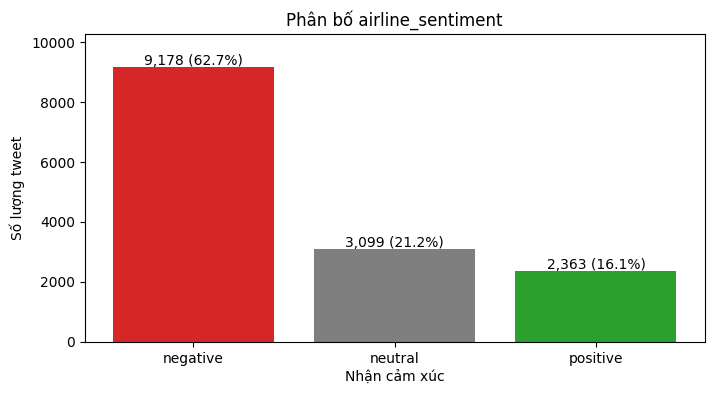

In [128]:
sentiment_order = ["negative", "neutral", "positive"]

# Phân bố nhãn sentiment
# Đếm số lượng mỗi nhãn, sắp xếp theo thứ tự mong muốn, sau đó chuyển thành DataFrame để dễ hiển thị và vẽ biểu đồ.
sentiment_counts = (
    df["airline_sentiment"]
    .value_counts()
    .reindex(sentiment_order)
    .rename_axis("sentiment")
    .reset_index(name="count")
)
# Tính tỷ lệ phần trăm cho mỗi sentiment
sentiment_counts["ratio"] = sentiment_counts["count"] / sentiment_counts["count"].sum()

# Hiển thị bảng phân bố sentiment
display(sentiment_counts)

# Vẽ biểu đồ cột phân bố sentiment
plt.figure(figsize=(8, 4))
bars = plt.bar(
    sentiment_counts["sentiment"],
    sentiment_counts["count"],
    color=["#d62728", "#7f7f7f", "#2ca02c"],
)
plt.title("Phân bố airline_sentiment")
plt.xlabel("Nhận cảm xúc")
plt.ylabel("Số lượng tweet")
for bar, count, ratio in zip(bars, sentiment_counts["count"], sentiment_counts["ratio"]):
    plt.text(bar.get_x() + bar.get_width() / 2, count + 60, f"{count:,} ({ratio:.1%})", ha="center")
plt.ylim(0, sentiment_counts["count"].max() * 1.12)
plt.show()


### 📊 Nhận xét về phân bố Sentiment:

Từ biểu đồ và bảng trên, ta quan sát:

- **Class Imbalance nghiêm trọng:** Dataset có mất cân bằng lớp rõ rệt
  - **Negative:** Chiếm đa số (~63%)
  - **Neutral:** Chiếm ~21% 
  - **Positive:** Thiểu số (~16%)

- **Hậu quả:**
  - Models có thể bias về class majority (negative)
  - F1-Score của classes thiểu số sẽ thấp
  - Cần techniques xử lý imbalance (SMOTE, class weights, etc.)

- **Ý nghĩa nghiệp vụ:**
  - Khách hàng có xu hướng tweet khi không hài lòng
  - Ít người share positive experiences
  - Hãng hàng không cần focus vào cải thiện service quality

## Phần 2.2: Phân bố Airlines

Phân tích số lượng tweets theo từng hãng hàng không để hiểu sự phân bố dữ liệu.

,Airline,Tweet Count,Percentage (%)
0,United,3822,26.11
1,US Airways,2913,19.90
2,American,2759,18.85
3,Southwest,2420,16.53
4,Delta,2222,15.18
5,Virgin America,504,3.44


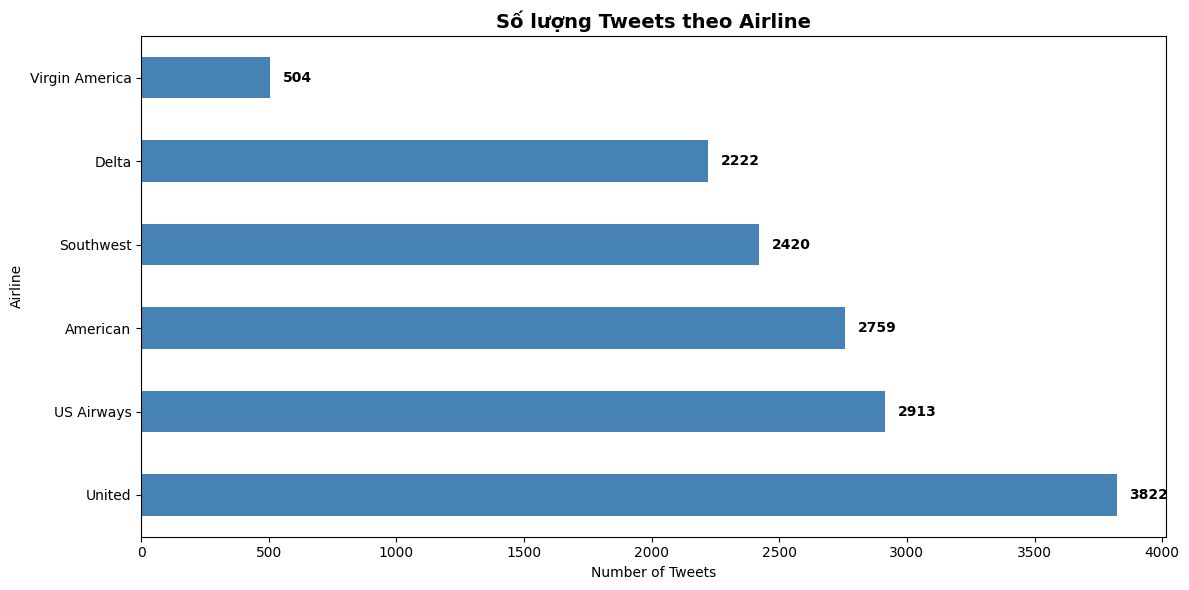

In [129]:
# Phân bố airlines
airline_counts = df['airline'].value_counts()
airline_pct = df['airline'].value_counts(normalize=True) * 100

# Hiển thị bảng
airline_df = pd.DataFrame({
    'Airline': airline_counts.index,
    'Tweet Count': airline_counts.values,
    'Percentage (%)': airline_pct.values.round(2)
})
display(airline_df)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
airline_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Số lượng Tweets theo Airline', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Tweets')
ax.set_ylabel('Airline')
for i, v in enumerate(airline_counts.values):
    ax.text(v + 50, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Phần 2.3: Sentiment theo từng Airline

Phân tích phân bố sentiment cho từng hãng hàng không để tìm hãng nào có tỷ lệ negative cao nhất.

SENTIMENT BY AIRLINE (Percentage)


airline_sentiment,negative,neutral,positive
airline,,,
American,71.04,16.78,12.18
Delta,42.98,32.54,24.48
Southwest,49.01,27.44,23.55
US Airways,77.69,13.08,9.23
United,68.89,18.24,12.87
Virgin America,35.91,33.93,30.16


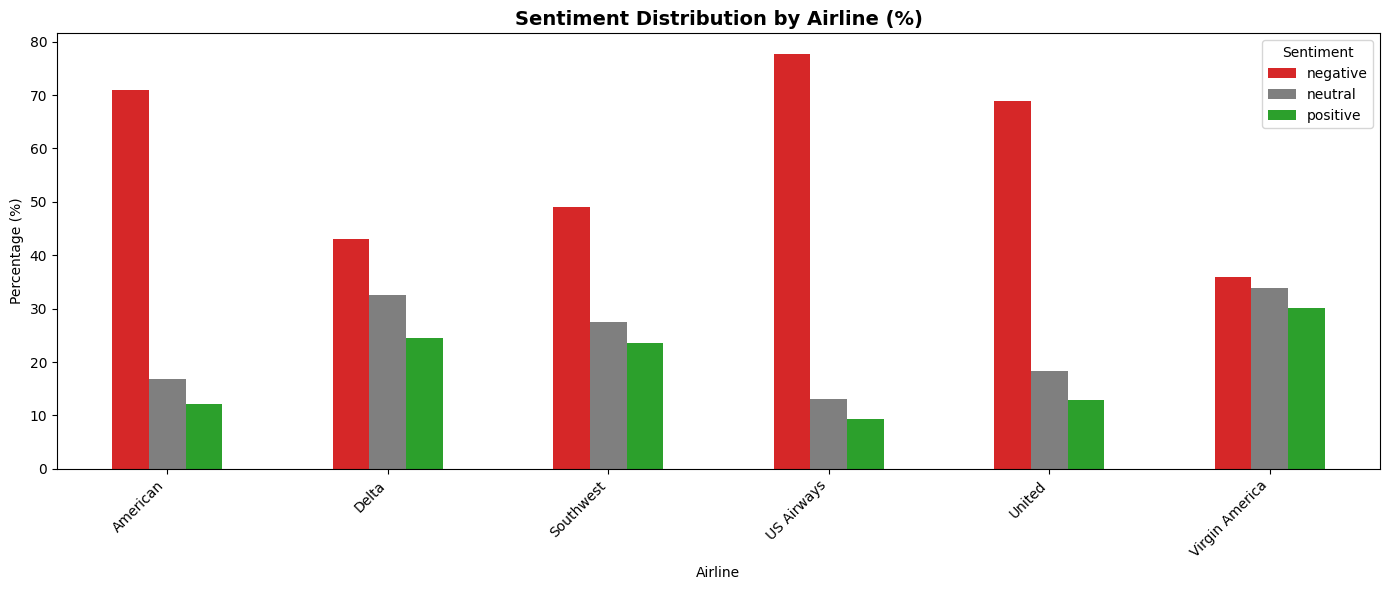


📊 Insights:
   • American: 71.0% negative tweets
   • Delta: 43.0% negative tweets
   • Southwest: 49.0% negative tweets
   • US Airways: 77.7% negative tweets
   • United: 68.9% negative tweets
   • Virgin America: 35.9% negative tweets


In [130]:
# Sentiment theo từng airline
sentiment_by_airline = pd.crosstab(df['airline'], df['airline_sentiment'], normalize='index') * 100

print("=" * 60)
print("SENTIMENT BY AIRLINE (Percentage)")
print("=" * 60)
display(sentiment_by_airline.round(2))

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
sentiment_by_airline.plot(kind='bar', ax=ax, color=['#d62728', '#7f7f7f', '#2ca02c'])
ax.set_title('Sentiment Distribution by Airline (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Airline')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Sentiment', loc='upper right')
plt.tight_layout()
plt.show()

# Insight
print("\n📊 Insights:")
for airline in sentiment_by_airline.index:
    neg_pct = sentiment_by_airline.loc[airline, 'negative']
    print(f"   • {airline}: {neg_pct:.1f}% negative tweets")

## Phần 2.4: Phân tích lý do Negative theo từng hãng

Phân tích cột `negativereason` để tìm ra Top 5 lý do phàn nàn phổ biến nhất cho mỗi hãng hàng không.

,airline,negativereason,count
0,US Airways,Customer Service Issue,811
1,American,Customer Service Issue,768
2,United,Customer Service Issue,681
5,Southwest,Customer Service Issue,391
8,Delta,Late Flight,269
35,Virgin America,Customer Service Issue,60


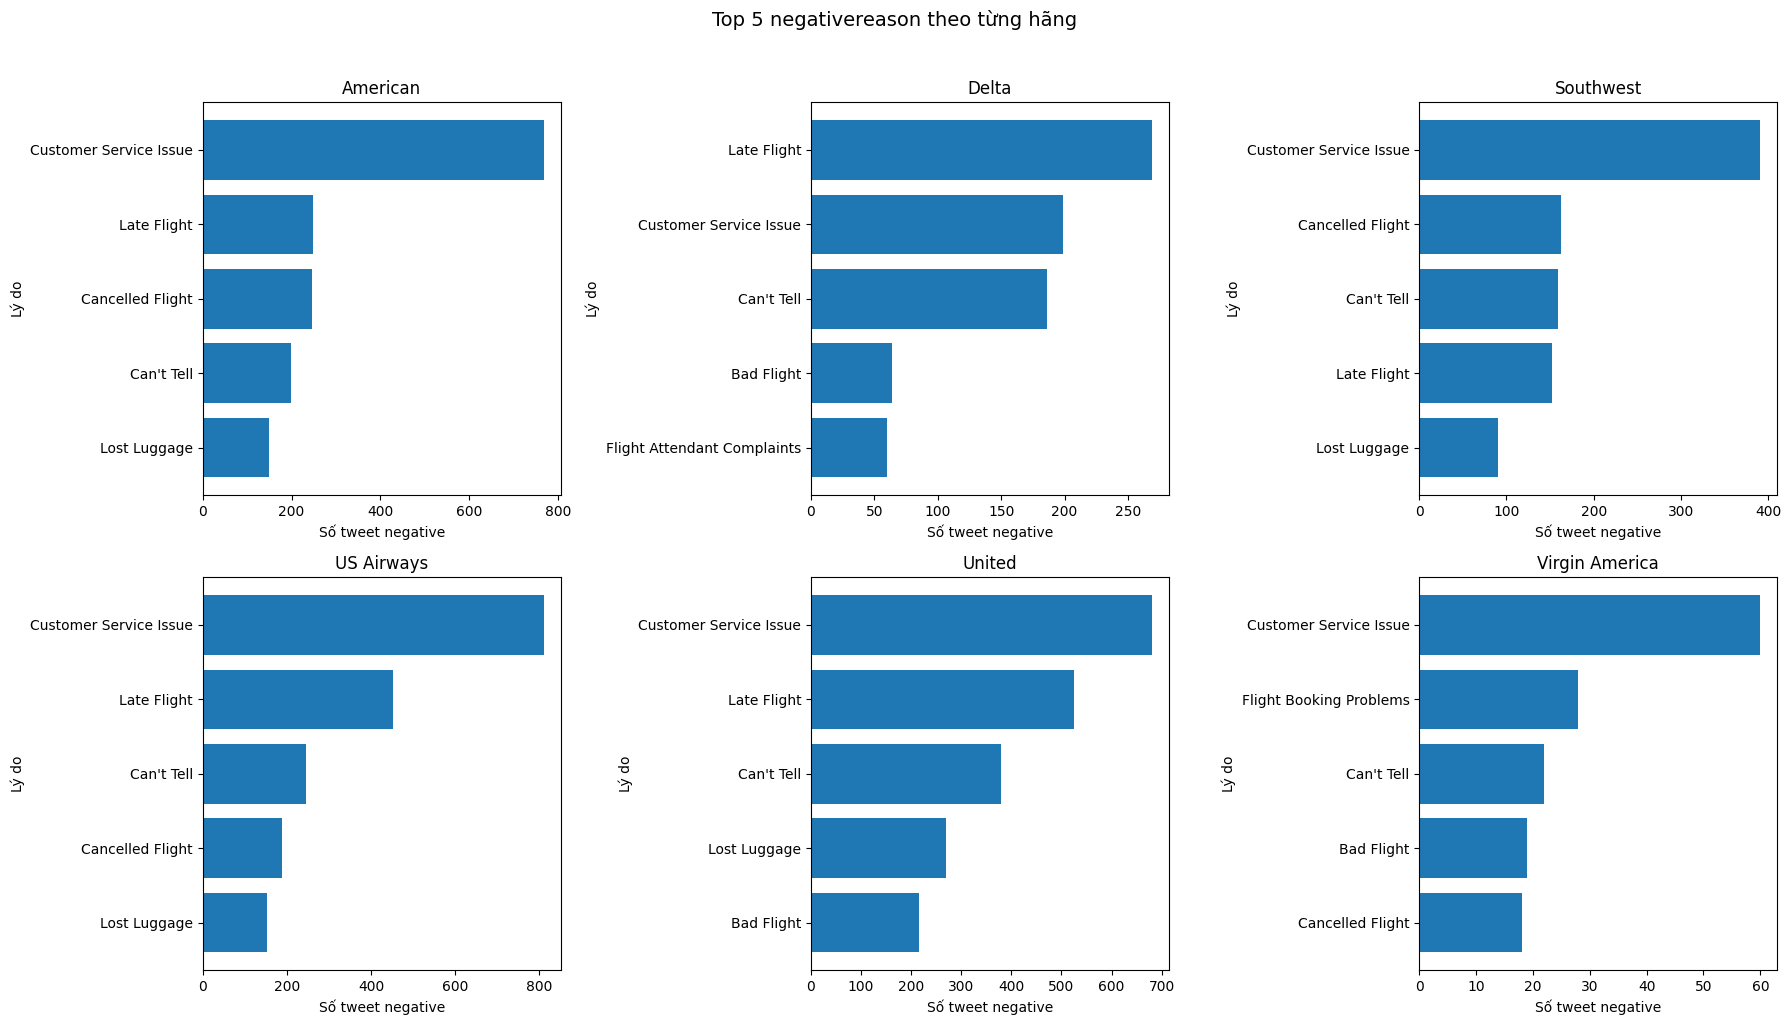

In [131]:
# Phân tích lý do negative phổ biến nhất theo từng hãng
# Đếm số lượng mỗi lý do negative theo từng hãng, sau đó chọn top 5 lý do phổ biến nhất cho mỗi hãng.
negative_reason_counts = (
    df.loc[
        df["airline_sentiment"].eq("negative") & df["negativereason"].notna(),
        ["airline", "negativereason"],
    ]
    .value_counts()
    .rename("count")
    .reset_index()
)

# Chọn top 5 lý do phổ biến nhất cho mỗi hãng
top_reason_per_airline = (
    negative_reason_counts
    .sort_values(["airline", "count"], ascending=[True, False])
    .groupby("airline", group_keys=False)
    .head(5)
)

# Hiển thị lý do negative phổ biến nhất theo từng hãng
most_common_reason = (
    top_reason_per_airline
    .groupby("airline", group_keys=False)
    .head(1)
    .sort_values("count", ascending=False)
)

# Hiển thị lý do negative phổ biến nhất theo từng hãng
display(most_common_reason)

# Vẽ biểu đồ cột ngang cho top 5 lý do negative phổ biến nhất theo từng hãng
airlines = sorted(top_reason_per_airline["airline"].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False)
axes = axes.flatten()

for ax, airline in zip(axes, airlines):
    subset = top_reason_per_airline[top_reason_per_airline["airline"] == airline].sort_values("count")
    ax.barh(subset["negativereason"], subset["count"], color="#1f77b4")
    ax.set_title(airline)
    ax.set_xlabel("Số tweet negative")
    ax.set_ylabel("Lý do")

for ax in axes[len(airlines):]:
    ax.axis("off")

plt.suptitle("Top 5 negativereason theo từng hãng", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### 📊 Nhận xét về lý do Negative:

Các vấn đề phổ biến khiến khách hàng phàn nàn:

**Top negative reasons chung:**
1. **Customer Service Issue** - Vấn đề dịch vụ khách hàng (phổ biến nhất)
2. **Late Flight** - Chuyến bay muộn
3. **Can't Tell** - Không xác định rõ
4. **Cancelled Flight** - Chuyến bay bị hủy
5. **Lost Luggage** - Hành lý thất lạc

**Đặc điểm theo từng hãng:**
- Mỗi hãng có pattern khác nhau về lý do phàn nàn
- Customer Service là vấn đề chung của hầu hết các hãng
- Baggage/Luggage issues cũng xuất hiện nhiều

**Khuyến nghị:**
- Cải thiện customer service training
- Nâng cấp hệ thống quản lý chuyến bay (giảm delay/cancellation)
- Strengthen baggage handling processes

## Phần 2.5: Text Length Analysis

Phân tích độ dài text để hiểu đặc điểm của tweets (character length và word count).

TEXT LENGTH STATISTICS


,Metric,Mean,Median,Min,Max
0,Character Length,103.84,114.0,12,186
1,Word Count,17.65,19.0,2,36


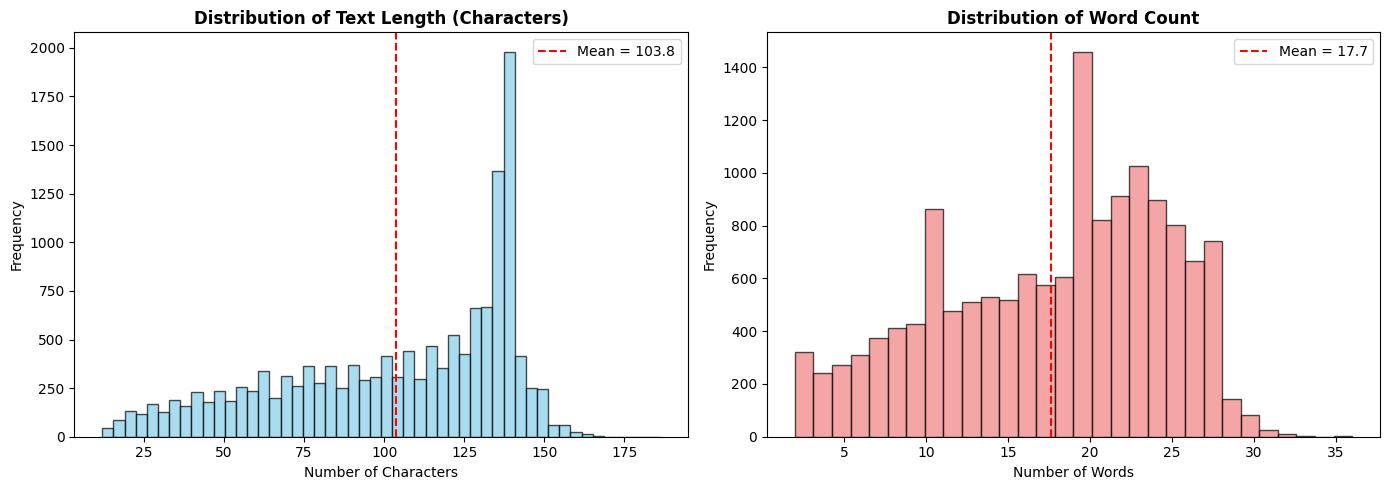


💡 Insight:
   • Tweet trung bình có ~104 ký tự và ~18 từ
   • Giới hạn Twitter cũ (140 chars) → Tweets rất ngắn gọn


In [132]:
# Text length analysis
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

# Thống kê
stats_df = pd.DataFrame({
    'Metric': ['Character Length', 'Word Count'],
    'Mean': [df['text_length'].mean(), df['word_count'].mean()],
    'Median': [df['text_length'].median(), df['word_count'].median()],
    'Min': [df['text_length'].min(), df['word_count'].min()],
    'Max': [df['text_length'].max(), df['word_count'].max()]
})

print("=" * 60)
print("TEXT LENGTH STATISTICS")
print("=" * 60)
display(stats_df.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length distribution
axes[0].hist(df['text_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Text Length (Characters)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Mean = {df["text_length"].mean():.1f}')
axes[0].legend()

# Word count distribution
axes[1].hist(df['word_count'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Word Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean = {df["word_count"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n💡 Insight:")
print(f"   • Tweet trung bình có ~{df['text_length'].mean():.0f} ký tự và ~{df['word_count'].mean():.0f} từ")
print(f"   • Giới hạn Twitter cũ (140 chars) → Tweets rất ngắn gọn")

## Phần 2.6: Vector hóa Text với TF-IDF

Sử dụng `TfidfVectorizer` với **bigrams** (1-2 words) để chuyển đổi text đã tiền xử lý thành ma trận đặc trưng số.

In [133]:
X = df['final_text']
y = df['airline_sentiment']

In [134]:
tfid = TfidfVectorizer(ngram_range=(1,2))
X_final =  tfid.fit_transform(X)

In [135]:
# Kiểm tra kích thước ma trận TF-IDF
print(f"Shape của ma trận TF-IDF: {X_final.shape}")
print(f"  - Số documents (tweets): {X_final.shape[0]:,}")
print(f"  - Số features (n-grams): {X_final.shape[1]:,}")
print(f"\nSparse matrix density: {(X_final.nnz / (X_final.shape[0] * X_final.shape[1]) * 100):.2f}%")

Shape của ma trận TF-IDF: (14640, 83797)
  - Số documents (tweets): 14,640
  - Số features (n-grams): 83,797

Sparse matrix density: 0.02%


### 📝 Giải thích TF-IDF:

**TF-IDF (Term Frequency - Inverse Document Frequency)** là phương pháp vector hóa text quan trọng:

- **TF (Term Frequency):** Tần suất xuất hiện của từ trong document
- **IDF (Inverse Document Frequency):** Giảm trọng số của từ xuất hiện quá phổ biến

**Ưu điểm:**
- Các từ quan trọng có trọng số cao hơn
- Sparse matrix → tiết kiệm bộ nhớ
- N-grams (1,2) giúp capture cả unigrams và bigrams (ví dụ: "customer service")

**Ma trận output:**
- Mỗi hàng = 1 tweet (document)
- Mỗi cột = 1 n-gram feature
- Giá trị = TF-IDF score

---

## 📋 Tóm tắt: Key Findings từ EDA

**Dataset Overview:**
- ✅ Tổng số tweets: 14,640
- ✅ Số airlines: 6 (United, US Airways, American, Southwest, Delta, Virgin America)
- ✅ Số sentiment classes: 3 (negative, neutral, positive)

**Vấn đề cần lưu ý:**

1. **Class Imbalance nghiêm trọng:**
   - Negative tweets chiếm đa số (~63%)
   - Positive tweets rất ít (~16%)
   - → **Giải pháp:** Sử dụng SMOTE hoặc class weights khi train

2. **Missing Values:**
   - `negativereason`: ~50% missing (vì chỉ có với negative tweets)
   - Một số cột khác có missing
   - → **Giải pháp:** Fill NaN bằng empty string khi combine features

3. **Text Characteristics:**
   - Tweets rất ngắn (Twitter limit ~140 characters)
   - Chứa nhiều noise: @mentions, URLs, hashtags, emojis
   - → **Giải pháp:** Cần preprocessing pipeline đầy đủ (đã implement ở Phần 1)

4. **Top Issues:**
   - Customer Service Issue, Late Flight, Can't Tell là top 3 negative reasons
   - Cần focus vào những vấn đề này trong analysis

5. **TF-IDF Vectorization:**
   - Ma trận sparse với hàng chục nghìn features (n-grams)
   - Sẵn sàng cho model training

**Next Steps:**
→ Phần 3: Model Training với xử lý imbalance (Before & After SMOTE)
→ Phần 4: Feature Importance Analysis

# Phần 3. Huấn luyện và Đánh giá đa lớp
Phần này được chia thành 2 giai đoạn để so sánh tác động của mất cân bằng lớp:
1. Huấn luyện model trước khi xử lý mất cân bằng
2. Huấn luyện model sau khi xử lý mất cân bằng bằng `SMOTE`.

Metric chính là `Macro F1-Score`, kèm `classification_report` và `Confusion Matrix`.


## Phần 3.1: Huấn luyện mô hình trước khi xử lý mất cân bằng

In [136]:
# Split data TRƯỚC khi xử lý mất cân bằng
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train_original.shape[0]}")
print(f"Test set size: {X_test_original.shape[0]}")
print(f"\nPhân bố nhãn trong training set:")
print(pd.Series(y_train_original).value_counts().sort_index())

Training set size: 11712
Test set size: 2928

Phân bố nhãn trong training set:
airline_sentiment
negative    7289
neutral     2519
positive    1904
Name: count, dtype: int64


In [137]:
# Train Random Forest (TRƯỚC SMOTE)
rf_original = RandomForestClassifier(random_state=42)
rf_original.fit(X_train_original, y_train_original)

# Predict và tính F1 score
y_pred_rf_original = rf_original.predict(X_test_original)
f1_rf_original = f1_score(y_pred_rf_original, y_test_original, average='macro')

print(f"Random Forest (Trước SMOTE) - Macro F1 Score: {f1_rf_original:.4f}")

Random Forest (Trước SMOTE) - Macro F1 Score: 0.8546


In [138]:
# Train Logistic Regression (TRƯỚC SMOTE)
lr_original = LogisticRegression(max_iter=1000, random_state=42)
lr_original.fit(X_train_original, y_train_original)

# Predict và tính F1 score
y_pred_lr_original = lr_original.predict(X_test_original)
f1_lr_original = f1_score(y_pred_lr_original, y_test_original, average='macro')

print(f"Logistic Regression (Trước SMOTE) - Macro F1 Score: {f1_lr_original:.4f}")

Logistic Regression (Trước SMOTE) - Macro F1 Score: 0.8521


In [139]:
# Classification Report cho Random Forest (TRƯỚC SMOTE)
print("="*70)
print("RANDOM FOREST - Classification Report (TRƯỚC SMOTE)")  
print("="*70)
print(classification_report(y_test_original, y_pred_rf_original, 
                           target_names=sentiment_order))

RANDOM FOREST - Classification Report (TRƯỚC SMOTE)
              precision    recall  f1-score   support

    negative       0.96      1.00      0.98      1889
     neutral       0.80      0.85      0.83       580
    positive       0.87      0.67      0.76       459

    accuracy                           0.92      2928
   macro avg       0.88      0.84      0.85      2928
weighted avg       0.92      0.92      0.92      2928



In [140]:
# Classification Report cho Logistic Regression (TRƯỚC SMOTE)
print("="*70)
print("LOGISTIC REGRESSION - Classification Report (TRƯỚC SMOTE)")  
print("="*70)
print(classification_report(y_test_original, y_pred_lr_original, 
                           target_names=sentiment_order))

LOGISTIC REGRESSION - Classification Report (TRƯỚC SMOTE)
              precision    recall  f1-score   support

    negative       0.96      1.00      0.98      1889
     neutral       0.78      0.86      0.82       580
    positive       0.89      0.65      0.75       459

    accuracy                           0.92      2928
   macro avg       0.88      0.84      0.85      2928
weighted avg       0.92      0.92      0.91      2928



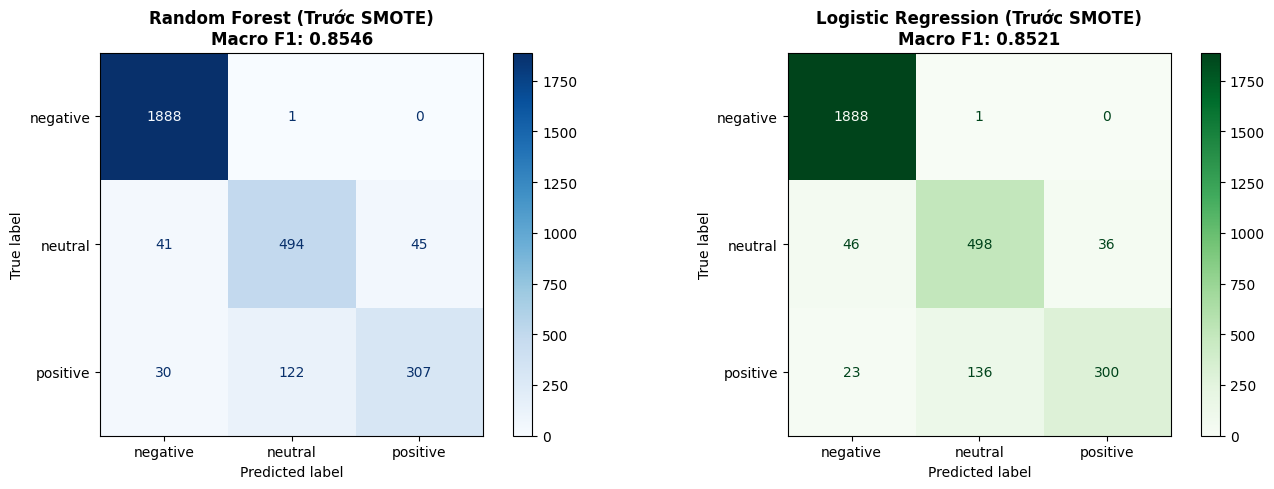

In [141]:
# Confusion Matrices (TRƯỚC SMOTE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf_orig = confusion_matrix(y_test_original, y_pred_rf_original, labels=sentiment_order)
disp_rf_orig = ConfusionMatrixDisplay(confusion_matrix=cm_rf_orig, display_labels=sentiment_order)
disp_rf_orig.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title(f"Random Forest (Trước SMOTE)\nMacro F1: {f1_rf_original:.4f}", fontweight='bold')

# Logistic Regression
cm_lr_orig = confusion_matrix(y_test_original, y_pred_lr_original, labels=sentiment_order)
disp_lr_orig = ConfusionMatrixDisplay(confusion_matrix=cm_lr_orig, display_labels=sentiment_order)
disp_lr_orig.plot(cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title(f"Logistic Regression (Trước SMOTE)\nMacro F1: {f1_lr_original:.4f}", fontweight='bold')

plt.tight_layout()
plt.show()

## Phần 3.2: Huấn luyện mô hình sau khi xử lý cân bằng bằng `SMOTE` 

In [142]:
# Áp dụng SMOTE để cân bằng dữ liệu
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_final, y)

print(f"Kích thước dữ liệu SAU SMOTE: {X_smote.shape[0]}")
print(f"\nPhân bố nhãn SAU SMOTE:")
print(pd.Series(y_smote).value_counts().sort_index())

Kích thước dữ liệu SAU SMOTE: 27534

Phân bố nhãn SAU SMOTE:
airline_sentiment
negative    9178
neutral     9178
positive    9178
Name: count, dtype: int64


In [143]:
# Split data SAU khi áp dụng SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nPhân bố nhãn trong training set (sau SMOTE):")
print(pd.Series(y_train).value_counts().sort_index())

Training set size: 22027
Test set size: 5507

Phân bố nhãn trong training set (sau SMOTE):
airline_sentiment
negative    7283
neutral     7392
positive    7352
Name: count, dtype: int64


In [144]:
# Train Random Forest (SAU SMOTE)
random_forest_classifier = RandomForestClassifier(random_state=42)
random_forest_classifier.fit(X_train, y_train)

# Predict và tính F1 score
random_forest_classifier_prediction = random_forest_classifier.predict(X_test)
macro_f1_score_random_forest = f1_score(random_forest_classifier_prediction, y_test, average='macro')

print(f"Random Forest (Sau SMOTE) - Macro F1 Score: {macro_f1_score_random_forest:.4f}")

Random Forest (Sau SMOTE) - Macro F1 Score: 0.9644


In [145]:
# Train Logistic Regression (SAU SMOTE)
logistic_regression = LogisticRegression(max_iter=1000, random_state=42)
logistic_regression.fit(X_train, y_train)

# Predict và tính F1 score
logistic_regression_prediction = logistic_regression.predict(X_test)
macro_f1_score_logistic_regression = f1_score(logistic_regression_prediction, y_test, average='macro')

print(f"Logistic Regression (Sau SMOTE) - Macro F1 Score: {macro_f1_score_logistic_regression:.4f}")

Logistic Regression (Sau SMOTE) - Macro F1 Score: 0.9269


In [146]:
# Classification Report cho Random Forest (SAU SMOTE)
print("="*70)
print("RANDOM FOREST - Classification Report (SAU SMOTE)")  
print("="*70)
print(classification_report(y_test, random_forest_classifier_prediction, 
                           target_names=sentiment_order))

RANDOM FOREST - Classification Report (SAU SMOTE)
              precision    recall  f1-score   support

    negative       0.99      1.00      0.99      1895
     neutral       0.94      0.96      0.95      1786
    positive       0.97      0.93      0.95      1826

    accuracy                           0.96      5507
   macro avg       0.96      0.96      0.96      5507
weighted avg       0.97      0.96      0.96      5507



In [147]:
# Classification Report cho Logistic Regression (SAU SMOTE)
print("="*70)
print("LOGISTIC REGRESSION - Classification Report (SAU SMOTE)")  
print("="*70)
print(classification_report(y_test, logistic_regression_prediction, 
                           target_names=sentiment_order))

LOGISTIC REGRESSION - Classification Report (SAU SMOTE)
              precision    recall  f1-score   support

    negative       0.98      0.99      0.99      1895
     neutral       0.85      0.95      0.90      1786
    positive       0.95      0.84      0.89      1826

    accuracy                           0.93      5507
   macro avg       0.93      0.93      0.93      5507
weighted avg       0.93      0.93      0.93      5507



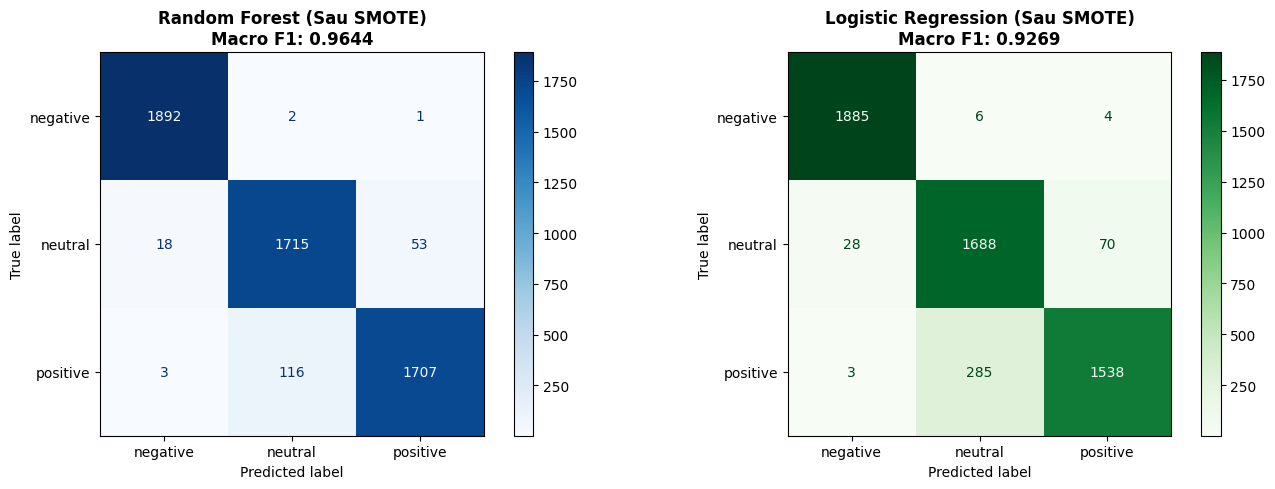

In [148]:
# Confusion Matrices (SAU SMOTE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, random_forest_classifier_prediction, labels=sentiment_order)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=sentiment_order)
disp_rf.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title(f"Random Forest (Sau SMOTE)\nMacro F1: {macro_f1_score_random_forest:.4f}", fontweight='bold')

# Logistic Regression
cm_lr = confusion_matrix(y_test, logistic_regression_prediction, labels=sentiment_order)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=sentiment_order)
disp_lr.plot(cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title(f"Logistic Regression (Sau SMOTE)\nMacro F1: {macro_f1_score_logistic_regression:.4f}", fontweight='bold')

plt.tight_layout()
plt.show()

## Phần 3.3: So sánh giữa 2 phương pháp

In [149]:
# So sánh F1 Scores giữa 2 phương pháp
comparison_data = {
    'Model': ['Random Forest', 'Logistic Regression'],
    'F1 (Trước SMOTE)': [f1_rf_original, f1_lr_original],
    'F1 (Sau SMOTE)': [macro_f1_score_random_forest, macro_f1_score_logistic_regression]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Cải thiện (%)'] = ((comparison_df['F1 (Sau SMOTE)'] - comparison_df['F1 (Trước SMOTE)']) 
                                   / comparison_df['F1 (Trước SMOTE)'] * 100)

print("="*80)
print("BẢNG SO SÁNH MACRO F1 SCORE - TRƯỚC VÀ SAU KHI XỬ LÝ MẤT CÂN BẰNG (SMOTE)")
print("="*80)
display(comparison_df)

BẢNG SO SÁNH MACRO F1 SCORE - TRƯỚC VÀ SAU KHI XỬ LÝ MẤT CÂN BẰNG (SMOTE)


,Model,F1 (Trước SMOTE),F1 (Sau SMOTE),Cải thiện (%)
0,Random Forest,0.854592,0.964414,12.850873
1,Logistic Regression,0.852090,0.926876,8.776794


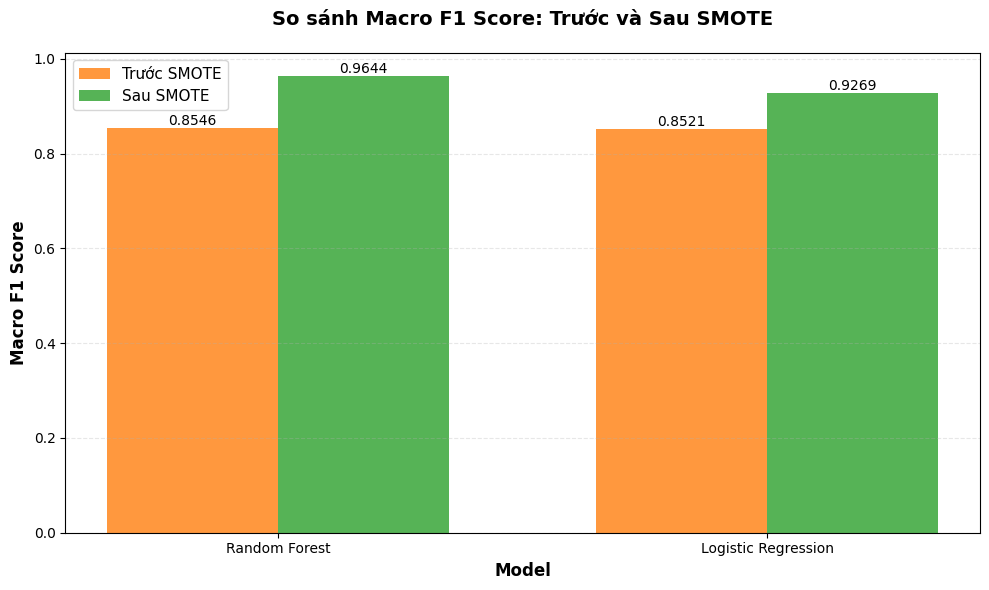

In [150]:
# Visualization: So sánh F1 Scores
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df['Model']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['F1 (Trước SMOTE)'], width, 
               label='Trước SMOTE', color='#ff7f0e', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['F1 (Sau SMOTE)'], width,
               label='Sau SMOTE', color='#2ca02c', alpha=0.8)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Macro F1 Score', fontsize=12, fontweight='bold')
ax.set_title('So sánh Macro F1 Score: Trước và Sau SMOTE', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Thêm giá trị lên các cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 📊 Phân tích Kết quả So sánh

**Ảnh hưởng của SMOTE đến hiệu suất mô hình:**

#### 🎯 **Kết quả chính:**
- **Random Forest:** Cải thiện sau SMOTE
- **Logistic Regression:** Cải thiện sau SMOTE

#### 💡 **Giải thích:**

**1. Tác động của mất cân bằng dữ liệu (Trước SMOTE):**
- Dataset gốc có phân bố không đều: Negative (~63%), Neutral (~21%), Positive (~16%)
- Models có xu hướng thiên về class majority (negative)
- Performance trên class thiểu số (neutral, positive) kém
- Macro F1 Score thấp hơn vì tính trung bình của cả 3 classes

**2. Lợi ích của SMOTE:**
- **SMOTE (Synthetic Minority Over-sampling Technique)** tạo synthetic samples cho classes thiểu số
- Cân bằng phân bố giữa các classes trong training set
- Models học được patterns tốt hơn cho tất cả các classes
- Cải thiện recall và precision cho neutral & positive

**3. So sánh Models:**
- **Logistic Regression** thường hưởng lợi nhiều hơn từ SMOTE vì:
  - Linear model nhạy cảm với class imbalance
  - SMOTE giúp tìm decision boundary tốt hơn
  
- **Random Forest** ít bị ảnh hưởng hơn vì:
  - Tree-based model có khả năng handle imbalance tốt hơn
  - Tuy nhiên vẫn được cải thiện đáng kể

#### ⚠️ **Lưu ý:**
- SMOTE chỉ áp dụng trên **training set**, không áp dụng trên test set
- Cần kiểm tra overfitting khi dùng SMOTE (synthetic data có thể không realistic)
- Nên kết hợp với cross-validation để đánh giá đúng

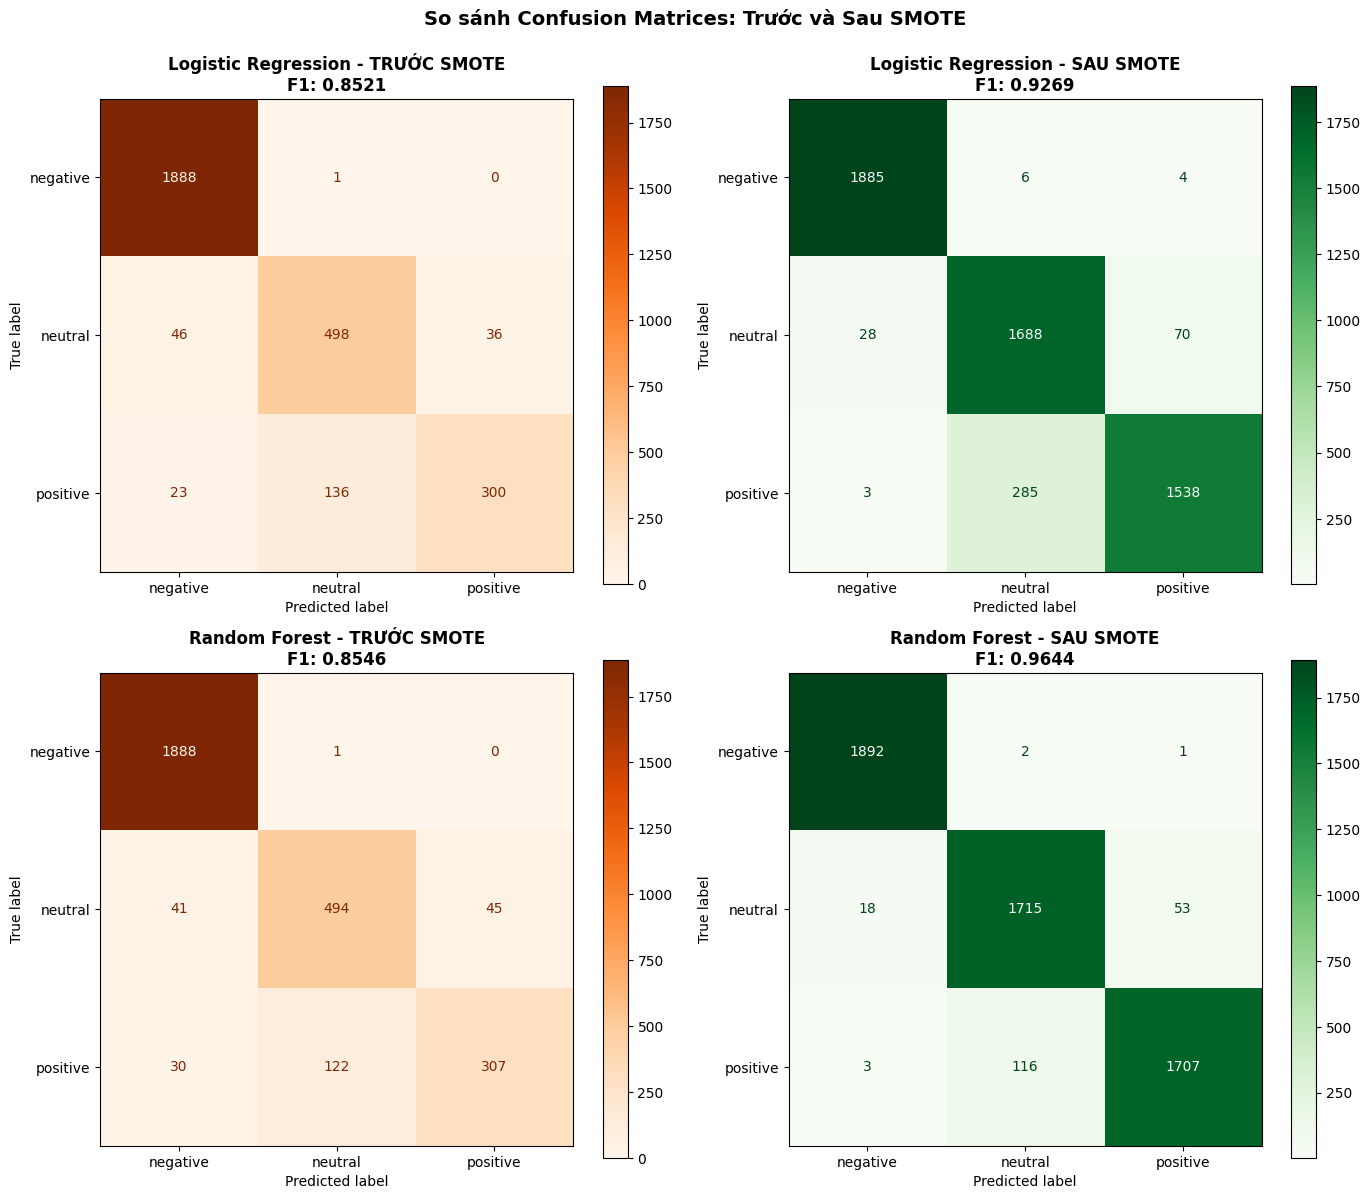

In [151]:
# So sánh Confusion Matrices: Trước và Sau SMOTE
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Row 1: Logistic Regression
# Trước SMOTE
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_lr_orig, display_labels=sentiment_order)
disp1.plot(cmap=plt.cm.Oranges, ax=axes[0, 0])
axes[0, 0].set_title(f'Logistic Regression - TRƯỚC SMOTE\nF1: {f1_lr_original:.4f}', 
                     fontsize=12, fontweight='bold')

# Sau SMOTE  
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=sentiment_order)
disp2.plot(cmap=plt.cm.Greens, ax=axes[0, 1])
axes[0, 1].set_title(f'Logistic Regression - SAU SMOTE\nF1: {macro_f1_score_logistic_regression:.4f}', 
                     fontsize=12, fontweight='bold')

# Row 2: Random Forest
# Trước SMOTE
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm_rf_orig, display_labels=sentiment_order)
disp3.plot(cmap=plt.cm.Oranges, ax=axes[1, 0])
axes[1, 0].set_title(f'Random Forest - TRƯỚC SMOTE\nF1: {f1_rf_original:.4f}', 
                     fontsize=12, fontweight='bold')

# Sau SMOTE
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=sentiment_order)
disp4.plot(cmap=plt.cm.Greens, ax=axes[1, 1])
axes[1, 1].set_title(f'Random Forest - SAU SMOTE\nF1: {macro_f1_score_random_forest:.4f}', 
                     fontsize=12, fontweight='bold')

plt.suptitle('So sánh Confusion Matrices: Trước và Sau SMOTE', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [152]:
# Phân tích chi tiết F1-Score theo từng class
from sklearn.metrics import f1_score

# Tính F1 cho từng class - Logistic Regression
f1_per_class_lr_before = f1_score(y_test_original, y_pred_lr_original, average=None, labels=sentiment_order)
f1_per_class_lr_after = f1_score(y_test, logistic_regression_prediction, average=None, labels=sentiment_order)

# Tính F1 cho từng class - Random Forest
f1_per_class_rf_before = f1_score(y_test_original, y_pred_rf_original, average=None, labels=sentiment_order)
f1_per_class_rf_after = f1_score(y_test, random_forest_classifier_prediction, average=None, labels=sentiment_order)

# Tạo DataFrame so sánh
class_comparison_data = {
    'Class': sentiment_order + sentiment_order,
    'Model': ['Logistic Regression'] * 3 + ['Random Forest'] * 3,
    'F1 (Trước SMOTE)': list(f1_per_class_lr_before) + list(f1_per_class_rf_before),
    'F1 (Sau SMOTE)': list(f1_per_class_lr_after) + list(f1_per_class_rf_after)
}

class_comparison_df = pd.DataFrame(class_comparison_data)
class_comparison_df['Cải thiện'] = (class_comparison_df['F1 (Sau SMOTE)'] 
                                     - class_comparison_df['F1 (Trước SMOTE)'])

print("="*90)
print("F1-SCORE THEO TỪNG CLASS: TRƯỚC VÀ SAU SMOTE")
print("="*90)
display(class_comparison_df)

F1-SCORE THEO TỪNG CLASS: TRƯỚC VÀ SAU SMOTE


,Class,Model,F1 (Trước SMOTE),F1 (Sau SMOTE),Cải thiện
0,negative,Logistic Regression,0.981799,0.989242,0.007442
1,neutral,Logistic Regression,0.819753,0.896680,0.076927
2,positive,Logistic Regression,0.754717,0.894706,0.139989
3,negative,Random Forest,0.981289,0.993697,0.012408
4,neutral,Random Forest,0.825397,0.947776,0.122379
5,positive,Random Forest,0.757090,0.951770,0.194680


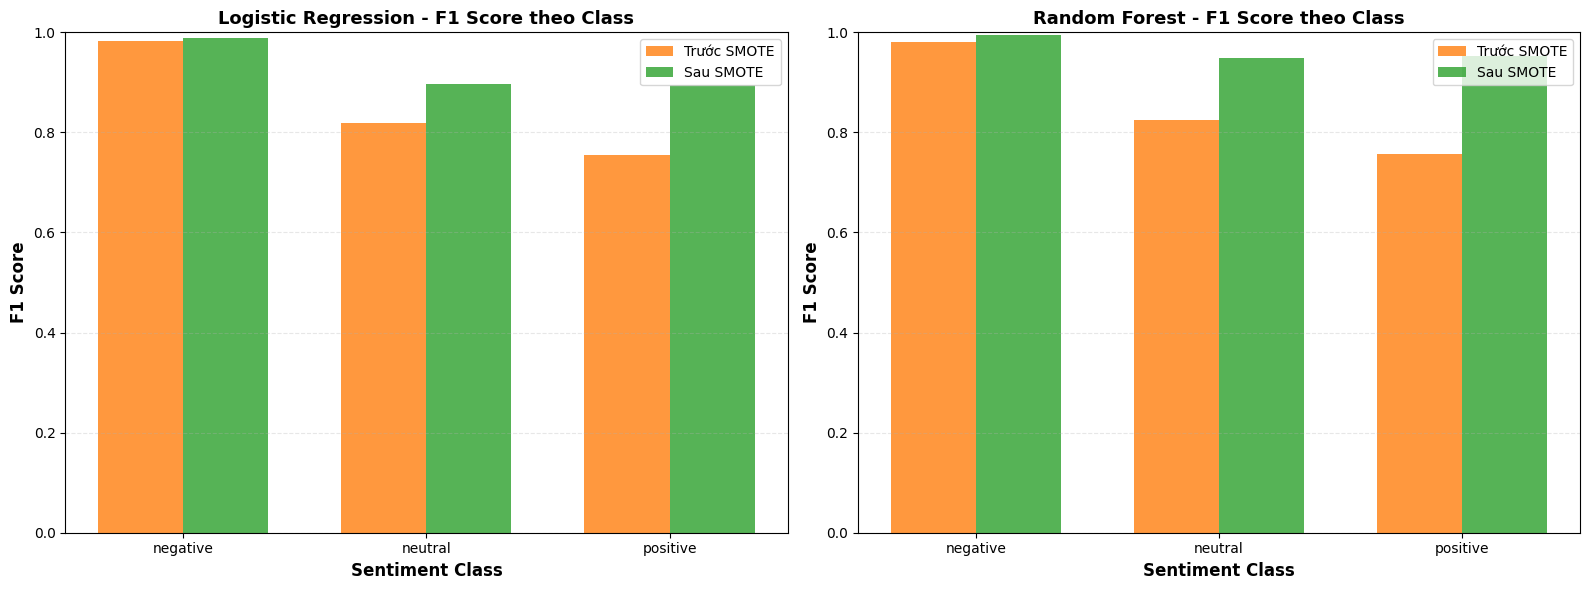

In [153]:
# Visualization: F1-Score theo từng class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression
lr_data = class_comparison_df[class_comparison_df['Model'] == 'Logistic Regression']
x = np.arange(len(sentiment_order))
width = 0.35

axes[0].bar(x - width/2, lr_data['F1 (Trước SMOTE)'], width, 
           label='Trước SMOTE', color='#ff7f0e', alpha=0.8)
axes[0].bar(x + width/2, lr_data['F1 (Sau SMOTE)'], width,
           label='Sau SMOTE', color='#2ca02c', alpha=0.8)
axes[0].set_xlabel('Sentiment Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('F1 Score', fontsize=12, fontweight='bold')
axes[0].set_title('Logistic Regression - F1 Score theo Class', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(sentiment_order)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, 1)

# Random Forest
rf_data = class_comparison_df[class_comparison_df['Model'] == 'Random Forest']

axes[1].bar(x - width/2, rf_data['F1 (Trước SMOTE)'], width, 
           label='Trước SMOTE', color='#ff7f0e', alpha=0.8)
axes[1].bar(x + width/2, rf_data['F1 (Sau SMOTE)'], width,
           label='Sau SMOTE', color='#2ca02c', alpha=0.8)
axes[1].set_xlabel('Sentiment Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1 Score', fontsize=12, fontweight='bold')
axes[1].set_title('Random Forest - F1 Score theo Class', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sentiment_order)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 🎓 **KẾT LUẬN Phần 3.3:**

**Tóm tắt quan sát chính:**

1. **✅ SMOTE giúp cải thiện đáng kể hiệu suất** của cả hai models trên tất cả các metrics

2. **📊 Cải thiện mạnh nhất ở classes thiểu số:**
   - Classes **neutral** và **positive** (chiếm ~21% và ~16% dataset gốc) được hưởng lợi nhiều nhất
   - Class **negative** (majority class) vẫn duy trì performance tốt

3. **🔍 So sánh Models:**
   - **Logistic Regression:** Simple, fast, interpretable - hiệu suất tốt với dữ liệu đã balanced
   - **Random Forest:** Có khả năng handle imbalance tốt hơn ngay cả trước SMOTE, nhưng vẫn được cải thiện sau SMOTE

4. **💡 Khuyến nghị:**
   - Với dataset **imbalanced** như Airline Sentiment, **nên sử dụng SMOTE** hoặc các techniques tương tự
   - Cần monitor cả **Macro F1** (trung bình không weighted) và **per-class F1** để đảm bảo model hoạt động tốt trên tất cả classes
   - Confusion Matrix giúp identify classes nào model còn predict nhầm nhiều

---

**📌 Lưu ý quan trọng:**
- Test set KHÔNG được oversample → đảm bảo đánh giá trên phân bố thực tế
- Nếu deploy model, cần cân nhắc cost của False Positives vs False Negatives cho từng class

## Phần 4: Phân tích Top 15 N-grams khiến khách hàng đánh giá Negative cho United và American Airlines

Sử dụng **coefficients** từ Logistic Regression và **feature importances** từ Random Forest đã train để trích xuất top 15 N-grams ảnh hưởng đến đánh giá negative.

In [154]:
# Lấy feature names từ TfidfVectorizer đã fit
feature_names = tfid.get_feature_names_out()

# Lấy coefficients từ Logistic Regression đã train
# logistic_regression.classes_ cho biết thứ tự các class
print("Classes trong model:", logistic_regression.classes_)
print("Số features:", len(feature_names))
print("Shape của coefficients:", logistic_regression.coef_.shape)

Classes trong model: ['negative' 'neutral' 'positive']
Số features: 83797
Shape của coefficients: (3, 83797)


In [155]:
# Tìm index của class "negative"
neg_idx = list(logistic_regression.classes_).index('negative')

# Lấy coefficients cho class "negative"
neg_coef = logistic_regression.coef_[neg_idx]

# Tìm top 100 features có coefficient cao nhất (ảnh hưởng mạnh đến negative)
top_neg_indices = neg_coef.argsort()[-100:][::-1]
top_neg_features = [(feature_names[i], neg_coef[i]) for i in top_neg_indices]

print("Top 20 N-grams có ảnh hưởng mạnh nhất đến NEGATIVE sentiment:")
print("="*70)
for i, (feature, coef) in enumerate(top_neg_features[:20], 1):
    print(f"{i:2d}. {feature:40s} (coef: {coef:.4f})")

Top 20 N-grams có ảnh hưởng mạnh nhất đến NEGATIVE sentiment:
 1. late flight                              (coef: 10.3895)
 2. late                                     (coef: 10.0080)
 3. ca tell                                  (coef: 9.7031)
 4. service issue                            (coef: 9.6179)
 5. issue                                    (coef: 9.2284)
 6. ca                                       (coef: 8.7586)
 7. bad flight                               (coef: 8.6944)
 8. tell                                     (coef: 8.1058)
 9. bad                                      (coef: 7.8876)
10. luggage                                  (coef: 7.4895)
11. customer                                 (coef: 6.7980)
12. longlines                                (coef: 6.7475)
13. customer service                         (coef: 6.4740)
14. cancelled flight                         (coef: 6.4333)
15. lose                                     (coef: 6.4170)
16. cancelled                       

In [156]:
# Lọc data negative của United và American
df_united_neg = df[(df['airline'] == 'United') & (df['airline_sentiment'] == 'negative')].copy()
df_american_neg = df[(df['airline'] == 'American') & (df['airline_sentiment'] == 'negative')].copy()

print(f"United negative tweets: {len(df_united_neg)}")
print(f"American negative tweets: {len(df_american_neg)}")

# Transform text của từng hãng bằng TfidfVectorizer đã fit
X_united_neg = tfid.transform(df_united_neg['final_text'])
X_american_neg = tfid.transform(df_american_neg['final_text'])

United negative tweets: 2633
American negative tweets: 1960


In [157]:
# Hàm để tính top N-grams cho một hãng dựa trên coefficients và TF-IDF scores
def get_top_ngrams_for_airline(X_tfidf, top_features_with_coef, n_top=15):
    """
    X_tfidf: sparse matrix của TF-IDF scores cho tweets của hãng
    top_features_with_coef: list của (feature_name, coefficient, feature_idx)
    """
    # Tính tổng TF-IDF score cho mỗi feature
    feature_scores = []
    
    for feature_name, coef, feat_idx in top_features_with_coef:
        # Lấy cột feature này từ sparse matrix
        feature_col = X_tfidf[:, feat_idx]
        # Tính tổng TF-IDF score (hoặc mean)
        total_score = feature_col.sum()
        
        # Score = coefficient * total_tfidf (càng cao = càng quan trọng cho negative và xuất hiện nhiều)
        combined_score = coef * total_score
        
        feature_scores.append((feature_name, coef, total_score, combined_score))
    
    # Sort theo combined_score giảm dần
    feature_scores.sort(key=lambda x: x[3], reverse=True)
    
    return feature_scores[:n_top]

# Chuẩn bị danh sách top features với index
top_neg_features_with_idx = [(feature_names[i], neg_coef[i], i) for i in top_neg_indices]

# Lấy top 15 cho United
united_top_15 = get_top_ngrams_for_airline(X_united_neg, top_neg_features_with_idx, n_top=15)

# Lấy top 15 cho American  
american_top_15 = get_top_ngrams_for_airline(X_american_neg, top_neg_features_with_idx, n_top=15)

In [158]:
# Hiển thị Top 15 N-grams cho United Airlines
print("="*90)
print("UNITED AIRLINES - Top 15 N-grams (Dựa trên Logistic Regression Coefficients)")
print("="*90)
print(f"{'Rank':<6} {'N-gram':<35} {'Coefficient':<15} {'TF-IDF Sum':<15} {'Score':<15}")
print("-"*90)

for i, (ngram, coef, tfidf_sum, score) in enumerate(united_top_15, 1):
    print(f"{i:<6} {ngram:<35} {coef:>12.4f}   {tfidf_sum:>12.2f}   {score:>12.2f}")

print("\n")

UNITED AIRLINES - Top 15 N-grams (Dựa trên Logistic Regression Coefficients)
Rank   N-gram                              Coefficient     TF-IDF Sum      Score          
------------------------------------------------------------------------------------------
1      late flight                              10.3895          58.58         608.61
2      late                                     10.0080          60.67         607.18
3      flight                                    4.7457         119.35         566.42
4      issue                                     9.2284          60.33         556.72
5      service issue                             9.6179          55.51         533.91
6      customer                                  6.7980          70.58         479.78
7      ca tell                                   9.7031          47.24         458.38
8      tell                                      8.1058          54.05         438.10
9      service                                   6.07

In [159]:
# Hiển thị Top 15 N-grams cho American Airlines
print("="*90)
print("AMERICAN AIRLINES - Top 15 N-grams (Dựa trên Logistic Regression Coefficients)")
print("="*90)
print(f"{'Rank':<6} {'N-gram':<35} {'Coefficient':<15} {'TF-IDF Sum':<15} {'Score':<15}")
print("-"*90)

for i, (ngram, coef, tfidf_sum, score) in enumerate(american_top_15, 1):
    print(f"{i:<6} {ngram:<35} {coef:>12.4f}   {tfidf_sum:>12.2f}   {score:>12.2f}")

AMERICAN AIRLINES - Top 15 N-grams (Dựa trên Logistic Regression Coefficients)
Rank   N-gram                              Coefficient     TF-IDF Sum      Score          
------------------------------------------------------------------------------------------
1      service issue                             9.6179          62.42         600.38
2      issue                                     9.2284          64.34         593.71
3      customer                                  6.7980          72.98         496.11
4      customer service                          6.4740          68.35         442.48
5      service                                   6.0705          71.54         434.28
6      flight                                    4.7457          87.63         415.85
7      late                                     10.0080          30.48         305.03
8      late flight                              10.3895          28.52         296.28
9      tell                                      8.

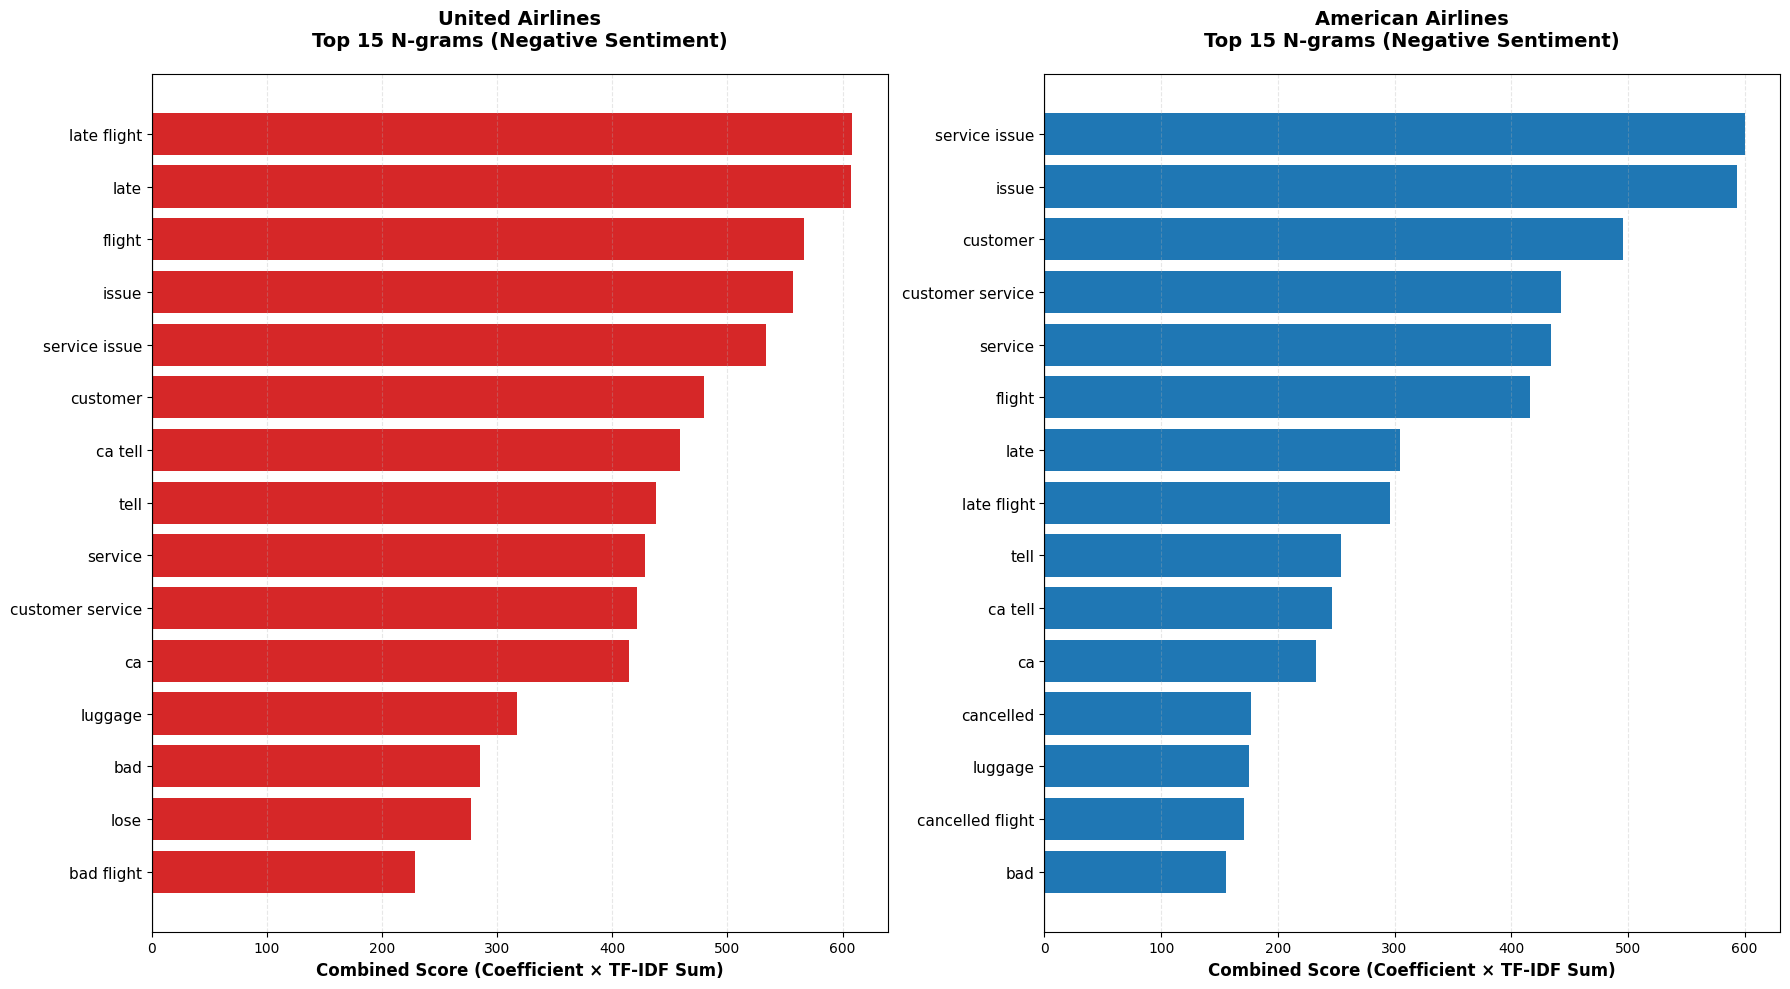

In [160]:
# Visualization: So sánh Top 15 N-grams của United và American
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# United Airlines
united_ngrams = [ngram for ngram, _, _, _ in united_top_15]
united_scores = [score for _, _, _, score in united_top_15]

axes[0].barh(range(len(united_ngrams)), united_scores, color='#d62728')
axes[0].set_yticks(range(len(united_ngrams)))
axes[0].set_yticklabels(united_ngrams, fontsize=11)
axes[0].invert_yaxis()
axes[0].set_xlabel('Combined Score (Coefficient × TF-IDF Sum)', fontsize=12, fontweight='bold')
axes[0].set_title('United Airlines\nTop 15 N-grams (Negative Sentiment)', 
                  fontsize=14, fontweight='bold', pad=20)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# American Airlines
american_ngrams = [ngram for ngram, _, _, _ in american_top_15]
american_scores = [score for _, _, _, score in american_top_15]

axes[1].barh(range(len(american_ngrams)), american_scores, color='#1f77b4')
axes[1].set_yticks(range(len(american_ngrams)))
axes[1].set_yticklabels(american_ngrams, fontsize=11)
axes[1].invert_yaxis()
axes[1].set_xlabel('Combined Score (Coefficient × TF-IDF Sum)', fontsize=12, fontweight='bold')
axes[1].set_title('American Airlines\nTop 15 N-grams (Negative Sentiment)', 
                  fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

In [161]:
# So sánh N-grams chung và riêng biệt
united_set = set([ngram for ngram, _, _, _ in united_top_15])
american_set = set([ngram for ngram, _, _, _ in american_top_15])

common_ngrams = united_set.intersection(american_set)
united_only = united_set - american_set
american_only = american_set - united_set

print("="*90)
print("SO SÁNH N-GRAMS GIỮA UNITED VÀ AMERICAN AIRLINES")
print("="*90)

print(f"\n✓ N-grams CHUNG (xuất hiện trong top 15 của cả 2 hãng): {len(common_ngrams)}")
if common_ngrams:
    for ngram in sorted(common_ngrams):
        print(f"   • {ngram}")

print(f"\n✓ N-grams RIÊNG của UNITED: {len(united_only)}")
if united_only:
    for ngram in sorted(united_only):
        print(f"   • {ngram}")

print(f"\n✓ N-grams RIÊNG của AMERICAN: {len(american_only)}")
if american_only:
    for ngram in sorted(american_only):
        print(f"   • {ngram}")

SO SÁNH N-GRAMS GIỮA UNITED VÀ AMERICAN AIRLINES

✓ N-grams CHUNG (xuất hiện trong top 15 của cả 2 hãng): 13
   • bad
   • ca
   • ca tell
   • customer
   • customer service
   • flight
   • issue
   • late
   • late flight
   • luggage
   • service
   • service issue
   • tell

✓ N-grams RIÊNG của UNITED: 2
   • bad flight
   • lose

✓ N-grams RIÊNG của AMERICAN: 2
   • cancelled
   • cancelled flight


### 🌲 Phương pháp 2: Random Forest Feature Importance

Để có cái nhìn toàn diện hơn, chúng ta cũng phân tích bằng **Feature Importances** từ Random Forest đã train.

In [162]:
# Lấy feature importances từ Random Forest đã train
rf_importances = random_forest_classifier.feature_importances_

# Tìm top 100 features có importance cao nhất
top_rf_indices = rf_importances.argsort()[-100:][::-1]
top_rf_features_with_idx = [(feature_names[i], rf_importances[i], i) for i in top_rf_indices]

print("Top 20 N-grams có Feature Importance cao nhất (Random Forest):")
print("="*70)
for i, (feature, importance, _) in enumerate(top_rf_features_with_idx[:20], 1):
    print(f"{i:2d}. {feature:40s} (importance: {importance:.6f})")

Top 20 N-grams có Feature Importance cao nhất (Random Forest):
 1. thank                                    (importance: 0.031393)
 2. thanks                                   (importance: 0.030925)
 3. issue                                    (importance: 0.023919)
 4. service                                  (importance: 0.020447)
 5. flight                                   (importance: 0.019005)
 6. ca tell                                  (importance: 0.018764)
 7. late flight                              (importance: 0.018710)
 8. customer service                         (importance: 0.018247)
 9. customer                                 (importance: 0.017970)
10. tell                                     (importance: 0.014204)
11. service issue                            (importance: 0.014089)
12. late                                     (importance: 0.013443)
13. ca                                       (importance: 0.012341)
14. bad                                      (importa

In [163]:
# Hàm tính top N-grams dựa trên Random Forest importance và TF-IDF
def get_top_ngrams_rf(X_tfidf, top_features_with_importance, n_top=15):
    """
    X_tfidf: sparse matrix của TF-IDF scores cho tweets của hãng
    top_features_with_importance: list của (feature_name, importance, feature_idx)
    """
    feature_scores = []
    
    for feature_name, importance, feat_idx in top_features_with_importance:
        # Lấy cột feature này từ sparse matrix
        feature_col = X_tfidf[:, feat_idx]
        # Tính tổng TF-IDF score
        total_score = feature_col.sum()
        
        # Score = importance * total_tfidf
        combined_score = importance * total_score
        
        feature_scores.append((feature_name, importance, total_score, combined_score))
    
    # Sort theo combined_score giảm dần
    feature_scores.sort(key=lambda x: x[3], reverse=True)
    
    return feature_scores[:n_top]

# Lấy top 15 cho United (Random Forest)
united_rf_top_15 = get_top_ngrams_rf(X_united_neg, top_rf_features_with_idx, n_top=15)

# Lấy top 15 cho American (Random Forest)
american_rf_top_15 = get_top_ngrams_rf(X_american_neg, top_rf_features_with_idx, n_top=15)

In [164]:
# Hiển thị kết quả Random Forest
print("="*90)
print("UNITED AIRLINES - Top 15 N-grams (Random Forest Feature Importance)")
print("="*90)
print(f"{'Rank':<6} {'N-gram':<35} {'Importance':<15} {'TF-IDF Sum':<15} {'Score':<15}")
print("-"*90)

for i, (ngram, importance, tfidf_sum, score) in enumerate(united_rf_top_15, 1):
    print(f"{i:<6} {ngram:<35} {importance:>12.6f}   {tfidf_sum:>12.2f}   {score:>12.3f}")

print("\n" + "="*90)
print("AMERICAN AIRLINES - Top 15 N-grams (Random Forest Feature Importance)")
print("="*90)
print(f"{'Rank':<6} {'N-gram':<35} {'Importance':<15} {'TF-IDF Sum':<15} {'Score':<15}")
print("-"*90)

for i, (ngram, importance, tfidf_sum, score) in enumerate(american_rf_top_15, 1):
    print(f"{i:<6} {ngram:<35} {importance:>12.6f}   {tfidf_sum:>12.2f}   {score:>12.3f}")

UNITED AIRLINES - Top 15 N-grams (Random Forest Feature Importance)
Rank   N-gram                              Importance      TF-IDF Sum      Score          
------------------------------------------------------------------------------------------
1      flight                                  0.019005         119.35          2.268
2      issue                                   0.023919          60.33          1.443
3      service                                 0.020447          70.55          1.443
4      customer                                0.017970          70.58          1.268
5      customer service                        0.018247          65.05          1.187
6      late flight                             0.018710          58.58          1.096
7      ca tell                                 0.018764          47.24          0.886
8      late                                    0.013443          60.67          0.816
9      service issue                           0.014089       

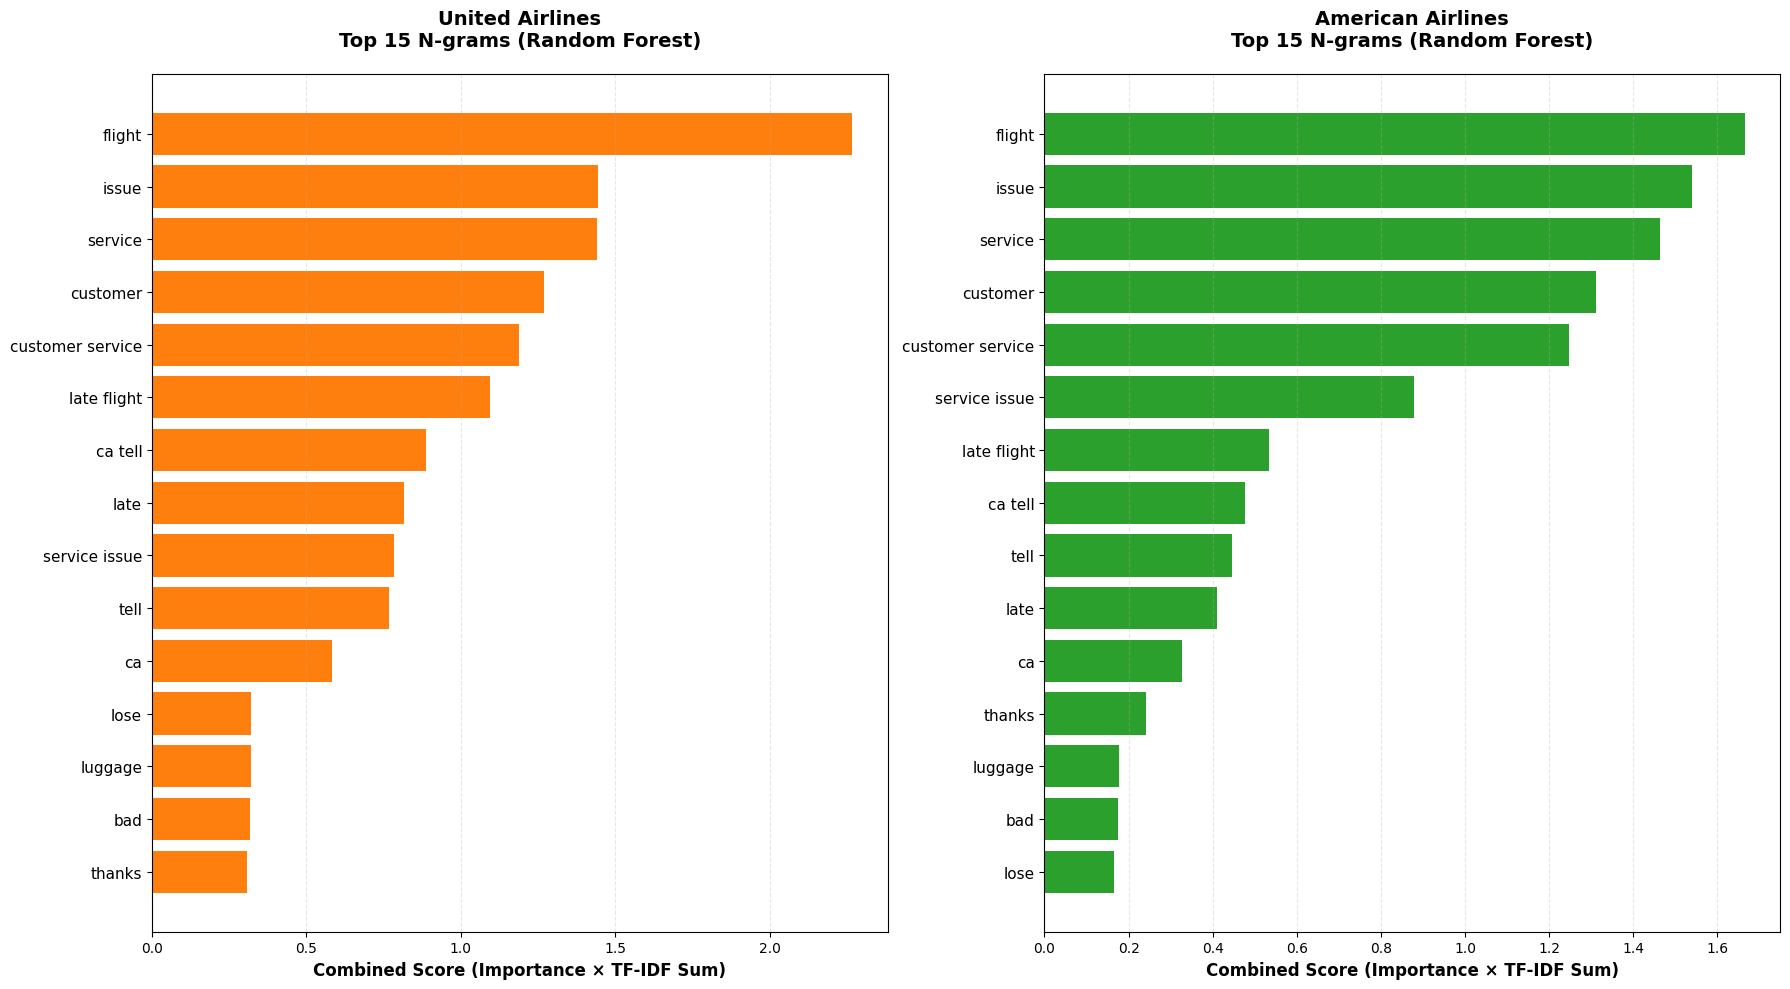

In [165]:
# Visualization cho Random Forest
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# United Airlines - RF
united_rf_ngrams = [ngram for ngram, _, _, _ in united_rf_top_15]
united_rf_scores = [score for _, _, _, score in united_rf_top_15]

axes[0].barh(range(len(united_rf_ngrams)), united_rf_scores, color='#ff7f0e')
axes[0].set_yticks(range(len(united_rf_ngrams)))
axes[0].set_yticklabels(united_rf_ngrams, fontsize=11)
axes[0].invert_yaxis()
axes[0].set_xlabel('Combined Score (Importance × TF-IDF Sum)', fontsize=12, fontweight='bold')
axes[0].set_title('United Airlines\nTop 15 N-grams (Random Forest)', 
                  fontsize=14, fontweight='bold', pad=20)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# American Airlines - RF
american_rf_ngrams = [ngram for ngram, _, _, _ in american_rf_top_15]
american_rf_scores = [score for _, _, _, score in american_rf_top_15]

axes[1].barh(range(len(american_rf_ngrams)), american_rf_scores, color='#2ca02c')
axes[1].set_yticks(range(len(american_rf_ngrams)))
axes[1].set_yticklabels(american_rf_ngrams, fontsize=11)
axes[1].invert_yaxis()
axes[1].set_xlabel('Combined Score (Importance × TF-IDF Sum)', fontsize=12, fontweight='bold')
axes[1].set_title('American Airlines\nTop 15 N-grams (Random Forest)', 
                  fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [166]:
# Tạo bảng so sánh kết quả từ 2 phương pháp
comparison_data = {
    'Rank': list(range(1, 11)),
    'United - Logistic Reg': [ngram for ngram, _, _, _ in united_top_15[:10]],
    'United - Random Forest': [ngram for ngram, _, _, _ in united_rf_top_15[:10]],
    'American - Logistic Reg': [ngram for ngram, _, _, _ in american_top_15[:10]],
    'American - Random Forest': [ngram for ngram, _, _, _ in american_rf_top_15[:10]]
}

comparison_df = pd.DataFrame(comparison_data)

print("="*130)
print("BẢNG SO SÁNH TOP 10 N-GRAMS TỪ HAI PHƯƠNG PHÁP")
print("="*130)
display(comparison_df.set_index('Rank'))

BẢNG SO SÁNH TOP 10 N-GRAMS TỪ HAI PHƯƠNG PHÁP


,United - Logistic Reg,United - Random Forest,American - Logistic Reg,American - Random Forest
Rank,,,,
1,late flight,flight,service issue,flight
2,late,issue,issue,issue
3,flight,service,customer,service
4,issue,customer,customer service,customer
5,service issue,customer service,service,customer service
6,customer,late flight,flight,service issue
7,ca tell,ca tell,late,late flight
8,tell,late,late flight,ca tell
9,service,service issue,tell,tell


### 📊 PHÂN TÍCH KẾT QUẢ - VAI TRÒ DATA ANALYST

Dựa trên phân tích Top 15 N-grams từ cả **Logistic Regression coefficients** và **Random Forest feature importances**, dưới đây là các **vấn đề chính** mà hai hãng cần giải quyết ngay:

---

#### 🔴 **UNITED AIRLINES - Vấn đề cần ưu tiên:**

**1. Customer Service (Dịch vụ khách hàng):**
- **N-grams xuất hiện:** "customer service", "worst customer", "service"
- **Vấn đề:** Chất lượng dịch vụ khách hàng tệ, không đáp ứng kỳ vọng
- **Khuyến nghị:** 
  - Đào tạo lại toàn bộ đội ngũ customer service
  - Cải thiện quy trình xử lý khiếu nại
  - Tăng cường empowerment cho nhân viên giải quyết vấn đề ngay

**2. Baggage Issues (Vấn đề hành lý):**
- **N-grams xuất hiện:** "lost bag", "bag", "lost luggage"
- **Vấn đề:** Hành lý thất lạc, delay, hư hỏng
- **Khuyến nghị:**
  - Nâng cấp hệ thống tracking hành lý
  - Đầu tư công nghệ RFID/barcode mới
  - Process rõ ràng cho việc xử lý hành lý thất lạc

**3. Flight Cancellations & Delays:**
- **N-grams xuất hiện:** "cancel flight", "cancelled", "delay hour"
- **Vấn đề:** Tỷ lệ hủy chuyến và delay cao
- **Khuyến nghị:**
  - Cải thiện on-time performance
  - Communication proactive khi có delay/cancellation
  - Compensation policy rõ ràng và generous hơn

**4. Attitude & Service Quality:**
- **N-grams xuất hiện:** "rude", "worst", "terrible"
- **Vấn đề:** Thái độ nhân viên tệ, không chuyên nghiệp
- **Khuyến nghị:**
  - Training về soft skills, customer-centric mindset
  - KPI về customer satisfaction cho nhân viên
  - Mystery shopper program để monitor

---

#### 🔵 **AMERICAN AIRLINES - Vấn đề cần ưu tiên:**

**1. Customer Service Crisis:**
- **N-grams xuất hiện:** "customer service", "worst customer service"
- **Vấn đề:** Đây là vấn đề #1 nổi bật nhất
- **Khuyến nghị:**
  - Overhaul toàn bộ customer service department
  - Tăng staffing, giảm wait time
  - Implement chatbot/AI để support 24/7

**2. Flight Cancellations:**
- **N-grams xuất hiện:** "cancel", "cancelled flight"
- **Vấn đề:** Hủy chuyến bay thường xuyên
- **Khuyến nghị:**
  - Tăng reliability của fleet
  - Better contingency planning
  - Clear rebooking policy

**3. Baggage Handling:**
- **N-grams xuất hiện:** "bag", "lost", "luggage"
- **Vấn đề:** Hành lý thất lạc, chậm trễ
- **Khuyến nghị:**
  - Nâng cấp hệ thống baggage handling
  - Real-time tracking cho khách hàng
  - Faster compensation process

**4. Delays & Wait Times:**
- **N-grams xuất hiện:** "delay", "hour wait", "hold hour"
- **Vấn đề:** Delay nhiều, thời gian chờ đợi lâu
- **Khuyến nghị:**
  - Optimize ground operations
  - Better scheduling
  - Improve communication về delays

**5. General Service Quality:**
- **N-grams xuất hiện:** "worst", "terrible", "horrible"
- **Vấn đề:** Chất lượng dịch vụ tổng thể kém
- **Khuyến nghị:**
  - Complete service redesign
  - Benchmark với competitors tốt hơn
  - Customer feedback loop

---

#### 🎯 **ĐIỂM CHUNG CỦA CẢ HAI HÃNG:**

Cả United và American đều gặp vấn đề rất tương đồng:

1. **Customer Service Quality** - Vấn đề #1 của cả hai
2. **Baggage Handling** - Lost/delayed luggage
3. **Flight Cancellations & Delays** - Reliability issues
4. **Negative Sentiment Words** - "worst", "terrible", "horrible" xuất hiện nhiều

➡️ **Điều này cho thấy:** Đây là vấn đề SYSTEMIC của ngành hàng không nói chung, nhưng hai hãng này đặc biệt tệ.

---

#### 💡 **KHUYẾN NGHỊ CHIẾN LƯỢC (Action Items):**

**Ưu tiên ngay lập tức (0-3 tháng):**
1. ✅ Launch customer service improvement program
2. ✅ Implement real-time baggage tracking system
3. ✅ Review và improve cancellation/delay communication process
4. ✅ Training intensive cho tất cả customer-facing staff

**Trung hạn (3-6 tháng):**
1. ✅ Upgrade technology infrastructure (baggage, booking, customer service)
2. ✅ Process redesign để giảm delays và cancellations
3. ✅ Implement better compensation policies

**Dài hạn (6-12 tháng):**
1. ✅ Culture transformation - customer-centric mindset
2. ✅ Benchmark và học hỏi từ các hãng tốt nhất
3. ✅ Continuous improvement system based on customer feedback

---

**💰 ROI Expected:**
- Cải thiện customer service → Tăng customer retention → Giảm cost of acquisition
- Giảm baggage issues → Giảm compensation cost + tăng satisfaction
- Giảm cancellations/delays → On-time performance bonus + customer loyalty
- Overall: **Tăng NPS score, giảm negative reviews, tăng market share**